# Bangalore Restaurant Pricing and Ratings Analysis (Zomato, 2022)

**Student:** Joyti Das  
**Programme:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 (BharatCares)  

---

## Project Question
> *What drives restaurant pricing and customer ratings in Bangalore, and can we predict the cost for two (AverageCost) from a restaurant's area, cuisines and services?*

## Dataset Source
- **Name:** Zomato Bangalore Restaurants 2022  
- **Author:** vora1011  
- **URL:** https://www.kaggle.com/datasets/vora1011/zomato-bangalore-restaurants-2022  
- **Collected:** March 2022  
- **Local file:** `BangaloreZomatoData.csv` (read-only — never modified)  

## How to Read This Notebook
Every code cell is preceded by a **markdown cell** that explains what the code does and why, in plain English.  
All tunable settings live in the **CONFIG cell** (Section 2) — change a number there and re-run to adjust the whole analysis.  
Sections are numbered 1–13 and build on each other, so run them **top to bottom** in order.

## Key Assumption
> **'Dinner Ratings' and 'Dinner Reviews' are treated as dine-in (sit-down) ratings/reviews throughout this notebook.**  
> The column name 'Dinner' appears to refer to dine-in service on the Zomato platform, not exclusively evening meals.

---
## Section 2 — Configuration

All tunable parameters are defined here in one place.  
This makes the notebook easy to reproduce and easy to explain in a review:  
- Change `RANDOM_STATE` to get a different random split (but always document it).  
- Change `TOP_N_CUISINES` to include more or fewer cuisine dummy columns.  
- Everything else in the notebook reads from these variables — no magic numbers buried in the code.

In [1]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
# All parameters are defined here. Every other cell reads from these variables.

RANDOM_STATE      = 42    # makes random operations reproducible
TEST_SIZE         = 0.20  # 80% train, 20% test
CV_FOLDS          = 5     # number of cross-validation folds
RATING_THRESHOLD  = 4.0   # a 'good' delivery rating is >= 4.0
OUTLIER_PERCENTILE= 99    # cap AverageCost charts at the 99th percentile
TOP_N_CUISINES    = 20    # create multi-hot columns for the 20 most common cuisines
TOP_N_AREAS       = 30    # top 30 areas kept by name; rest become 'Other' in modelling
CHAIN_MIN_OUTLETS = 5     # a restaurant name appearing >= 5 times is flagged as a chain

DATA_FILE         = 'BangaloreZomatoData.csv'   # source file (read-only)
CLEAN_FILE        = 'data/zomato_cleaned.csv'   # output cleaned file
FIGURES_DIR       = 'figures'                   # all charts saved here

print('CONFIG loaded:')
print(f'  RANDOM_STATE={RANDOM_STATE}, TEST_SIZE={TEST_SIZE}, CV_FOLDS={CV_FOLDS}')
print(f'  RATING_THRESHOLD={RATING_THRESHOLD}, OUTLIER_PERCENTILE={OUTLIER_PERCENTILE}')
print(f'  TOP_N_CUISINES={TOP_N_CUISINES}, TOP_N_AREAS={TOP_N_AREAS}, CHAIN_MIN_OUTLETS={CHAIN_MIN_OUTLETS}')

CONFIG loaded:
  RANDOM_STATE=42, TEST_SIZE=0.2, CV_FOLDS=5
  RATING_THRESHOLD=4.0, OUTLIER_PERCENTILE=99
  TOP_N_CUISINES=20, TOP_N_AREAS=30, CHAIN_MIN_OUTLETS=5


---
## Section 3 — Data Loading and Audit

This section loads the raw CSV exactly as it came from Kaggle — no changes yet.  
We look at:  
1. **Shape** — how many rows and columns  
2. **Column names and data types** — are numbers stored as text?  
3. **Missing values** — both actual blanks (NaN) AND the literal string `"-"` used in rating columns  
4. **Duplicates** — are any full rows identical?  
5. **Unique counts** — how many distinct areas, cuisine strings, restaurant names?  

### Why we check for `"-"` separately
Pandas reads `"-"` as a string, not as a missing value.  
So a simple `df.isnull().sum()` would *under-count* missing ratings.  
We count both: real NaN **and** the `"-"` placeholder.

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120   # sharper charts

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('data', exist_ok=True)

# ── Load raw data ───────────────────────────────────────────────────────────
# keep_default_na=True so that blank cells are already NaN.
# We do NOT pass na_values='-' yet because we want to count '-' separately first.
df_raw = pd.read_csv(DATA_FILE, keep_default_na=True)

print('=' * 60)
print(f'RAW SHAPE: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print('=' * 60)

RAW SHAPE: 8923 rows × 19 columns


In [3]:
# ── Column names, dtypes, and a sample value for each column ────────────────
print(f'{"Column":<25} {"Dtype":<15} {"Sample value"}')
print('-' * 70)
for col in df_raw.columns:
    sample = df_raw[col].dropna().iloc[0] if df_raw[col].notna().any() else 'ALL NULL'
    print(f'{col:<25} {str(df_raw[col].dtype):<15} {str(sample)[:50]}')

Column                    Dtype           Sample value
----------------------------------------------------------------------
Name                      str             Sri Udupi Park
URL                       str             https://www.zomato.com/bangalore/sri-udupi-park-in
Cuisines                  str             South Indian, North Indian, Chinese, Street Food, 
Area                      str             Indiranagar, Bangalore
Timing                    str             7am – 11pm (Today)
Full_Address              str             273, Monalisa, 6th Main, 100 Feet Road, Indiranaga
PhoneNumber               str             +919945977774
IsHomeDelivery            int64           1
isTakeaway                int64           1
isIndoorSeating           int64           1
isVegOnly                 int64           1
Dinner Ratings            str             4.0
Dinner Reviews            int64           462
Delivery Ratings          str             4.1
Delivery Reviews          int64           

In [4]:
# ── Missing-value audit ─────────────────────────────────────────────────────
# For rating columns we also count the literal string '-' as missing.

total_rows = len(df_raw)

def missing_report(df):
    """Return a DataFrame showing NaN count, dash-string count, total missing,
    and missing % for every column."""
    rating_cols = ['Dinner Ratings', 'Delivery Ratings']
    rows = []
    for col in df.columns:
        nan_count  = df[col].isna().sum()
        dash_count = (df[col] == '-').sum() if df[col].dtype == object else 0
        total_miss = nan_count + dash_count
        rows.append({
            'Column'         : col,
            'NaN'            : nan_count,
            'Dash("-")'      : dash_count,
            'Total Missing'  : total_miss,
            'Missing %'      : round(100 * total_miss / len(df), 2)
        })
    return pd.DataFrame(rows)

miss_raw = missing_report(df_raw)
print('MISSING VALUE AUDIT (raw data)')
print(miss_raw.to_string(index=False))

MISSING VALUE AUDIT (raw data)
          Column  NaN  Dash("-")  Total Missing  Missing %
            Name    0          0              0       0.00
             URL    0          0              0       0.00
        Cuisines    0          0              0       0.00
            Area    0          0              0       0.00
          Timing 3103          0           3103      34.78
    Full_Address    0          0              0       0.00
     PhoneNumber    0          0              0       0.00
  IsHomeDelivery    0          0              0       0.00
      isTakeaway    0          0              0       0.00
 isIndoorSeating    0          0              0       0.00
       isVegOnly    0          0              0       0.00
  Dinner Ratings    0          0              0       0.00
  Dinner Reviews    0          0              0       0.00
Delivery Ratings    0          0              0       0.00
Delivery Reviews    0          0              0       0.00
        KnownFor 8665    

In [5]:
# ── Duplicate rows ──────────────────────────────────────────────────────────
dup_count = df_raw.duplicated().sum()
print(f'Fully duplicated rows: {dup_count}')
print('(A "duplicated row" means every single column is identical to another row.)')
print()

# ── Chain check: restaurant names that repeat ───────────────────────────────
name_counts = df_raw['Name'].value_counts()
chains_raw = name_counts[name_counts >= CHAIN_MIN_OUTLETS]
print(f'Restaurant names appearing >= {CHAIN_MIN_OUTLETS} times (chains): {len(chains_raw)}')
print(f'Rows belonging to chains: {chains_raw.sum()}')
print()

# ── Unique counts ───────────────────────────────────────────────────────────
print(f'Unique restaurant names : {df_raw["Name"].nunique()}')
print(f'Unique Area values      : {df_raw["Area"].nunique()}')
print(f'Unique Cuisines strings : {df_raw["Cuisines"].nunique()}')
print()

# Count individual cuisines after splitting on comma
all_cuisines = (
    df_raw['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
print(f'Unique individual cuisines (after split): {all_cuisines.nunique()}')

Fully duplicated rows: 0
(A "duplicated row" means every single column is identical to another row.)

Restaurant names appearing >= 5 times (chains): 294
Rows belonging to chains: 2986

Unique restaurant names : 5242
Unique Area values      : 169
Unique Cuisines strings : 2939

Unique individual cuisines (after split): 101


In [6]:
# ── AverageCost range check ─────────────────────────────────────────────────
print('AverageCost summary (raw):')
print(df_raw['AverageCost'].describe().round(2))
print(f'\nMedian AverageCost: {df_raw["AverageCost"].median()}')

# ── D-7 verification: do zero Dinner Reviews always pair with "-" ratings? ───
print('\n── D-7 CHECK: Dinner Reviews=0 vs Dinner Ratings="-" ──')
zero_rev   = df_raw[df_raw['Dinner Reviews'] == 0]
dash_rating = df_raw[df_raw['Dinner Ratings'] == '-']
zero_with_dash  = zero_rev[zero_rev['Dinner Ratings'] == '-'].shape[0]
zero_without_dash = zero_rev[zero_rev['Dinner Ratings'] != '-'].shape[0]
dash_with_nonzero = dash_rating[dash_rating['Dinner Reviews'] != 0].shape[0]
print(f'Rows where Dinner Reviews=0 AND Dinner Ratings="-": {zero_with_dash}')
print(f'Rows where Dinner Reviews=0 BUT Dinner Ratings != "-": {zero_without_dash}')
print(f'Rows where Dinner Ratings="-" BUT Dinner Reviews != 0: {dash_with_nonzero}')
print('Conclusion: zero reviews do NOT always pair with missing ratings (see counts above).')
print('The 47 rows with zero reviews but a valid rating, and the 490 rows with a')
print('missing rating but non-zero reviews, show unexplained patterns; possible')
print('reasons include scraping inconsistencies or delayed rating updates.')
print('Cause is not verified. Both columns are handled independently:')
print('log1p(reviews) for feature engineering; NaN ratings remain NaN throughout.')


AverageCost summary (raw):
count    8923.00
mean      340.23
std       308.34
min        50.00
25%       150.00
50%       250.00
75%       400.00
max      4200.00
Name: AverageCost, dtype: float64

Median AverageCost: 250.0

── D-7 CHECK: Dinner Reviews=0 vs Dinner Ratings="-" ──
Rows where Dinner Reviews=0 AND Dinner Ratings="-": 4835
Rows where Dinner Reviews=0 BUT Dinner Ratings != "-": 47
Rows where Dinner Ratings="-" BUT Dinner Reviews != 0: 490
Conclusion: zero reviews do NOT always pair with missing ratings (see counts above).
The 47 rows with zero reviews but a valid rating, and the 490 rows with a
missing rating but non-zero reviews, show unexplained patterns; possible
reasons include scraping inconsistencies or delayed rating updates.
Cause is not verified. Both columns are handled independently:
log1p(reviews) for feature engineering; NaN ratings remain NaN throughout.


---
## Section 4 — KPI Definitions and RAW KPI Values

A **KPI (Key Performance Indicator)** is a specific, measurable number that tells us something important about the dataset.  
We define each KPI with its formula first, then compute it on the **raw** data (before any cleaning).  
In Section 6 we will compute the same KPIs again after cleaning and compare them side by side.

### KPI Formulas

| # | KPI | Formula |
|---|-----|---------|
| K1 | Total restaurants | `len(df)` |
| K2 | Median AverageCost | `df['AverageCost'].median()` |
| K3 | Mean AverageCost | `df['AverageCost'].mean()` |
| K4 | Mean Delivery Rating (rated only) | `df[rated]['Delivery Ratings'].astype(float).mean()` where `rated` = rows where value ≠ '-' |
| K5 | Count of rated restaurants (delivery) | `(df['Delivery Ratings'] != '-') & df['Delivery Ratings'].notna()` |
| K6 | Share rated delivery >= 4.0 | `(rated_delivery_ratings >= 4.0).sum() / len(rated_delivery)` |
| K7 | Delivery rating coverage % | `K5 / K1 * 100` |
| K8 | Dinner rating coverage % | `count(Dinner Ratings not '-' and not NaN) / K1 * 100` |
| K9 | Top-10 Areas by count | `df['Area'].value_counts().head(10)` |
| K10 | Top-10 Cuisines by appearance | `split + explode + value_counts().head(10)` |
| K11 | Service mix % | `df[flag_col].sum() / K1 * 100` for each flag |
| K12 | Chain count (names >= 5 outlets) | `(name_counts >= CHAIN_MIN_OUTLETS).sum()` |
| K13 | Median cost by top-10 Area | `df.groupby('Area')['AverageCost'].median()` (top 10 areas) |
| K14 | Mean delivery rating by top-10 Cuisine | group by exploded cuisine |

> All formulas use the cleaned area name (without ', Bangalore') from Section 5 onward.  
> Here in Section 4 we compute on raw data — area still contains ', Bangalore'.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — Raw KPI Computation
# We work on df_raw and do NOT modify it.
# '-' is treated as missing for all rating calculations.
# ─────────────────────────────────────────────────────────────────────────────

# K1 — Total restaurants
k1_total = len(df_raw)

# K2, K3 — Cost statistics
k2_median_cost = df_raw['AverageCost'].median()
k3_mean_cost   = df_raw['AverageCost'].mean()

# Delivery ratings: replace '-' with NaN, then convert to float for arithmetic
del_rat_raw = pd.to_numeric(df_raw['Delivery Ratings'].replace('-', np.nan), errors='coerce')
din_rat_raw = pd.to_numeric(df_raw['Dinner Ratings'].replace('-', np.nan),   errors='coerce')

# K4, K5, K6, K7 — Delivery rating KPIs
k5_del_rated_count = del_rat_raw.notna().sum()
k4_mean_del_rating = del_rat_raw.mean()               # mean of rated only (NaN ignored)
k6_share_del_gte4  = (del_rat_raw >= RATING_THRESHOLD).sum() / k5_del_rated_count * 100
k7_del_coverage    = k5_del_rated_count / k1_total * 100

# K8 — Dinner rating coverage
k8_din_coverage    = din_rat_raw.notna().sum() / k1_total * 100

# K9 — Top-10 Areas by restaurant count
k9_top_areas = df_raw['Area'].value_counts().head(10)

# K10 — Top-10 individual cuisines
k10_top_cuisines = (
    df_raw['Cuisines'].dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

# K11 — Service mix
service_cols = ['IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly']
k11_service_mix = {col: df_raw[col].sum() / k1_total * 100 for col in service_cols}

# K12 — Chain concentration
name_counts_raw = df_raw['Name'].value_counts()
k12_chain_names = (name_counts_raw >= CHAIN_MIN_OUTLETS).sum()
k12_chain_rows  = name_counts_raw[name_counts_raw >= CHAIN_MIN_OUTLETS].sum()

# K13 — Median cost by top-10 areas (raw; area includes ', Bangalore')
top10_areas_list = k9_top_areas.index.tolist()
k13_median_cost_area = (
    df_raw[df_raw['Area'].isin(top10_areas_list)]
    .groupby('Area')['AverageCost']
    .median()
    .sort_values(ascending=False)
)

# K14 — Mean delivery rating by top-10 cuisines
df_exploded = df_raw.copy()
df_exploded['del_rat_numeric'] = del_rat_raw
df_exploded['cuisine_item'] = df_exploded['Cuisines'].str.split(',')
df_exploded = df_exploded.explode('cuisine_item')
df_exploded['cuisine_item'] = df_exploded['cuisine_item'].str.strip()
top10_cuisine_list = k10_top_cuisines.index.tolist()
k14_rating_by_cuisine = (
    df_exploded[df_exploded['cuisine_item'].isin(top10_cuisine_list)]
    .groupby('cuisine_item')['del_rat_numeric']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print('RAW KPI VALUES')
print('=' * 50)
print(f'K1  Total restaurants              : {k1_total}')
print(f'K2  Median AverageCost (₹)         : {k2_median_cost:.0f}')
print(f'K3  Mean AverageCost (₹)           : {k3_mean_cost:.1f}')
print(f'K4  Mean Delivery Rating (rated)   : {k4_mean_del_rating:.3f}')
print(f'K5  Rated restaurants (delivery)   : {k5_del_rated_count}')
print(f'K6  Share rated delivery >= {RATING_THRESHOLD}  : {k6_share_del_gte4:.1f}%')
print(f'K7  Delivery rating coverage       : {k7_del_coverage:.1f}%')
print(f'K8  Dinner rating coverage         : {k8_din_coverage:.1f}%')
print(f'K12 Chain names (>= {CHAIN_MIN_OUTLETS} outlets)    : {k12_chain_names}')
print(f'K12 Chain restaurant rows          : {k12_chain_rows}')
print()
print('K9  Top-10 Areas by restaurant count:')
print(k9_top_areas.to_string())
print()
print('K10 Top-10 Cuisines by appearance:')
print(k10_top_cuisines.to_string())
print()
print('K11 Service mix (% of restaurants):')
for col, pct in k11_service_mix.items():
    print(f'    {col:<25}: {pct:.1f}%')
print()
print('K13 Median cost by top-10 area (raw):')
print(k13_median_cost_area.round(0).to_string())
print()
print('K14 Mean delivery rating by top-10 cuisine:')
print(k14_rating_by_cuisine.to_string())

RAW KPI VALUES


K1  Total restaurants              : 8923
K2  Median AverageCost (₹)         : 250
K3  Mean AverageCost (₹)           : 340.2
K4  Mean Delivery Rating (rated)   : 3.879
K5  Rated restaurants (delivery)   : 7792
K6  Share rated delivery >= 4.0  : 48.7%
K7  Delivery rating coverage       : 87.3%
K8  Dinner rating coverage         : 40.3%
K12 Chain names (>= 5 outlets)    : 294
K12 Chain restaurant rows          : 2986

K9  Top-10 Areas by restaurant count:
Area
Electronic City, Bangalore    674
Marathahalli, Bangalore       484
HSR, Bangalore                457
Whitefield, Bangalore         447
BTM, Bangalore                397
Indiranagar, Bangalore        292
JP Nagar, Bangalore           292
Sarjapur Road, Bangalore      284
Rajajinagar, Bangalore        237
New BEL Road, Bangalore       232

K10 Top-10 Cuisines by appearance:
Cuisines
North Indian    3249
Beverages       2829
Chinese         2765
Desserts        2320
Fast Food       2173
Biryani         1987
South Indian    1644
Str

---
## Section 5 — Data Cleaning

We clean the data in **11 documented steps**.  
For each step there is a markdown cell explaining *what* and *why*, followed by the code cell.  
The original `df_raw` is never changed — all work is done on a copy called `df`.

### Cleaning decisions (approved by student before writing this code)
| Decision | Choice |
|----------|--------|
| Timing column | **Dropped entirely** — too sparse and scrape-time dependent |
| KnownFor / PopularDishes / PeopleKnownFor | **Dropped** — too sparse for modelling |
| Rating missing values | **Never imputed** — left as NaN |
| AverageCost outliers | **No rows deleted** — use log1p for modelling; cap charts at 99th percentile |
| Cuisines | Split into list; multi-hot dummies for top 20 cuisines |

**Step log:**
1. Drop PII / unused columns: URL, PhoneNumber, Full_Address  
2. Drop sparse text columns: Timing, KnownFor, PopularDishes, PeopleKnownFor  
3. Replace `"-"` with NaN in Dinner Ratings and Delivery Ratings  
4. Convert Dinner Ratings, Delivery Ratings to float  
5. Convert Dinner Reviews, Delivery Reviews to int  
6. Convert flag columns (IsHomeDelivery, isTakeaway, isIndoorSeating, isVegOnly) to int (0/1)  
7. Strip `", Bangalore"` from Area; strip whitespace from Name, Area, Cuisines  
8. Handle Cuisines: store as list and create top-N multi-hot dummy columns  
9. Drop rows where AverageCost is NaN (target column — can't model without it)  
10. Save `data/zomato_cleaned.csv`

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 0 — Make a working copy; NEVER touch df_raw
# ─────────────────────────────────────────────────────────────────────────────
df = df_raw.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (8923, 19)


### Step 1 & 2 — Drop unnecessary columns

- **URL, PhoneNumber, Full_Address**: personally identifiable / contact information. Not useful for analysis and must be excluded from any saved file.
- **Timing**: dropped by student decision — it is ~35% missing and records the scrape-time opening status, not a stable feature.
- **KnownFor, PopularDishes, PeopleKnownFor**: free-text columns that are very sparse (>60% missing). They cannot be reliably used in modelling.

In [9]:
# STEP 1 & 2 — Drop columns
# 'errors=ignore' means: if a column is already absent, don't crash.
drop_cols = [
    'URL', 'PhoneNumber', 'Full_Address',          # PII / not useful
    'Timing',                                       # sparse, scrape-time dependent
    'KnownFor', 'PopularDishes', 'PeopleKnownFor'  # too sparse for modelling
]
df.drop(columns=drop_cols, errors='ignore', inplace=True)
print(f'After dropping unused columns: {df.shape}')
print('Remaining columns:', df.columns.tolist())

After dropping unused columns: (8923, 12)
Remaining columns: ['Name', 'Cuisines', 'Area', 'IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly', 'Dinner Ratings', 'Dinner Reviews', 'Delivery Ratings', 'Delivery Reviews', 'AverageCost']


### Steps 3 & 4 — Fix rating columns

The rating columns (`Dinner Ratings`, `Delivery Ratings`) store a `"-"` string when a restaurant has no ratings yet.  
We replace `"-"` with `NaN` (Python's standard "not a number" / missing marker), then convert the column to float.  
**We do NOT fill in (impute) these missing values** — inventing a rating would distort the analysis.

In [10]:
# STEP 3 & 4 — Replace '-' with NaN, then convert ratings to float
for col in ['Dinner Ratings', 'Delivery Ratings']:
    before = (df[col] == '-').sum()
    df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
    after_nan = df[col].isna().sum()
    print(f'{col}: "-" count before = {before:,}  |  NaN count after = {after_nan:,}')

Dinner Ratings: "-" count before = 5,325  |  NaN count after = 5,325
Delivery Ratings: "-" count before = 1,131  |  NaN count after = 1,131


### Step 5 — Fix review count columns

`Dinner Reviews` and `Delivery Reviews` should be whole numbers (you can't have 0.5 reviews).  
We convert them to integer type. `errors='coerce'` turns any unexpected text into `NaN` rather than crashing.

In [11]:
# STEP 5 — Convert review counts to integer
for col in ['Dinner Reviews', 'Delivery Reviews']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    print(f'{col}: dtype = {df[col].dtype}, max = {df[col].max():,}')

Dinner Reviews: dtype = int64, max = 26,500
Delivery Reviews: dtype = int64, max = 99,600


### Step 6 — Convert flag columns to integer (0/1)

The four service flag columns (`IsHomeDelivery`, `isTakeaway`, `isIndoorSeating`, `isVegOnly`) should be 0 or 1.  
We convert them explicitly so that pandas treats them as numbers, not objects.

In [12]:
# STEP 6 — Convert flag columns to int (0 / 1)
flag_cols = ['IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly']
for col in flag_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    vals = df[col].unique()
    print(f'{col}: unique values = {sorted(vals)}')

IsHomeDelivery: unique values = [np.int64(0), np.int64(1)]
isTakeaway: unique values = [np.int64(0), np.int64(1)]
isIndoorSeating: unique values = [np.int64(0), np.int64(1)]
isVegOnly: unique values = [np.int64(0), np.int64(1)]


### Step 7 — Clean Area and text columns

Every `Area` value ends with `", Bangalore"` (e.g. `"Indiranagar, Bangalore"`).  
We strip that suffix so the area name is just `"Indiranagar"`.  
We also strip extra spaces from `Name`, `Area`, and `Cuisines`.

In [13]:
# STEP 7 — Strip ', Bangalore' from Area; strip whitespace from text columns
df['Area'] = df['Area'].str.replace(r',\s*Bangalore$', '', regex=True).str.strip()
df['Name'] = df['Name'].str.strip()
df['Cuisines'] = df['Cuisines'].str.strip()

print('Sample Area values after cleaning:')
print(df['Area'].dropna().head(5).tolist())

Sample Area values after cleaning:
['Indiranagar', 'Indiranagar', 'Indiranagar', 'Indiranagar', 'Indiranagar']


### Step 8 — Handle Cuisines: split into list and create multi-hot dummy columns

Each `Cuisines` cell holds several cuisines separated by commas (e.g. `"Biryani, North Indian, Chinese"`).  
We split each cell into a Python list. Then we create **multi-hot** (also called dummy or indicator) columns —  
one column per top-N cuisine, with value 1 if that restaurant serves that cuisine, 0 otherwise.  

Why only the top-N?  
There are ~100 unique cuisines. Creating a column for each would make the feature matrix very wide and sparse.  
We keep only the 20 most common cuisines (controlled by `TOP_N_CUISINES` in CONFIG).  
We also store a `CuisineList` column (the raw list) for feature engineering in Section 7.

In [14]:
# STEP 8 — Split Cuisines into a list; create multi-hot columns for top-N cuisines

# 8a. Split each cell into a list (NaN becomes an empty list)
df['CuisineList'] = (
    df['Cuisines']
    .fillna('')
    .str.split(',')
    .apply(lambda items: [x.strip() for x in items if x.strip()])
)

# 8b. Find the top-N cuisine names across the whole dataset
all_cuisines_series = df['CuisineList'].explode()
top_cuisines = (
    all_cuisines_series
    .value_counts()
    .head(TOP_N_CUISINES)
    .index
    .tolist()
)
print(f'Top {TOP_N_CUISINES} cuisines selected:')
print(top_cuisines)

# 8c. Create one binary column per top cuisine
# Column name format: 'cui_NorthIndian' (spaces replaced by underscores)
for cuisine in top_cuisines:
    col_name = 'cui_' + cuisine.replace(' ', '_').replace('/', '_')
    df[col_name] = df['CuisineList'].apply(lambda lst: 1 if cuisine in lst else 0)

cuisine_dummy_cols = [c for c in df.columns if c.startswith('cui_')]
print(f'\nCreated {len(cuisine_dummy_cols)} cuisine dummy columns.')
print('Sample cuisine dummy sums (how many restaurants serve each):')
print(df[cuisine_dummy_cols].sum().sort_values(ascending=False).to_string())

Top 20 cuisines selected:
['North Indian', 'Beverages', 'Chinese', 'Desserts', 'Fast Food', 'Biryani', 'South Indian', 'Street Food', 'Shake', 'Mughlai', 'Ice Cream', 'Bakery', 'Pizza', 'Burger', 'Rolls', 'Seafood', 'Kebab', 'Sandwich', 'Momos', 'Andhra']



Created 20 cuisine dummy columns.
Sample cuisine dummy sums (how many restaurants serve each):


cui_North_Indian    3249
cui_Beverages       2829
cui_Chinese         2765
cui_Desserts        2320
cui_Fast_Food       2173
cui_Biryani         1987
cui_South_Indian    1644
cui_Street_Food     1089
cui_Shake            927
cui_Mughlai          826
cui_Ice_Cream        810
cui_Bakery           591
cui_Pizza            518
cui_Burger           515
cui_Rolls            507
cui_Seafood          471
cui_Kebab            444
cui_Sandwich         428
cui_Momos            379
cui_Andhra           300


### Step 9 — Check AverageCost and handle target

We do **not** delete any rows because of AverageCost outliers.  
We do drop the very small number of rows (if any) where AverageCost is missing entirely —  
without a target value it is impossible to train or evaluate a regression model.

For charts: we will cap the display at the 99th percentile (set by `OUTLIER_PERCENTILE` in CONFIG).  
For modelling: we will apply `log1p(AverageCost)` to compress the range.

In [15]:
# STEP 9 — Check and handle AverageCost
before_rows = len(df)
cost_null = df['AverageCost'].isna().sum()
print(f'Rows with missing AverageCost: {cost_null}')

if cost_null > 0:
    df.dropna(subset=['AverageCost'], inplace=True)
    print(f'Dropped {cost_null} rows where AverageCost is missing (cannot model without target).')
else:
    print('No rows dropped — AverageCost has no missing values.')

print(f'Rows: {before_rows} → {len(df)}')

# Document the 99th percentile for chart capping
cost_99p = df['AverageCost'].quantile(OUTLIER_PERCENTILE / 100)
print(f'\nAverageCost 99th percentile: ₹{cost_99p:.0f}')
print('Charts will cap display at this value. No rows are deleted.')

Rows with missing AverageCost: 0
No rows dropped — AverageCost has no missing values.
Rows: 8923 → 8923

AverageCost 99th percentile: ₹1600
Charts will cap display at this value. No rows are deleted.


### Step 10 — Save cleaned data to CSV

We save the cleaned dataset to `data/zomato_cleaned.csv`.  
Final checks before saving:  
- URL, PhoneNumber, Full_Address columns are **absent** (confirmed below)  
- The `CuisineList` column is a Python list object — we convert it to a string for CSV storage  

In [16]:
# STEP 10 — Final check and save

# Confirm PII columns are gone
pii_cols = ['URL', 'PhoneNumber', 'Full_Address']
present_pii = [c for c in pii_cols if c in df.columns]
if present_pii:
    print(f'WARNING: PII columns still present: {present_pii}')
else:
    print('PII check PASSED: URL, PhoneNumber, Full_Address are absent from cleaned data.')

# Convert CuisineList (Python list) to a pipe-separated string for CSV storage
# This avoids messy quoting/escaping issues in CSV
df['CuisineListStr'] = df['CuisineList'].apply(lambda lst: '|'.join(lst))

# Save (excluding the Python-list column itself; keep the string version)
save_df = df.drop(columns=['CuisineList'])
save_df.to_csv(CLEAN_FILE, index=False)
print(f'\nCleaned data saved to: {CLEAN_FILE}')
print(f'Shape saved: {save_df.shape}')
print(f'Columns saved: {save_df.columns.tolist()}')

PII check PASSED: URL, PhoneNumber, Full_Address are absent from cleaned data.



Cleaned data saved to: data/zomato_cleaned.csv
Shape saved: (8923, 33)
Columns saved: ['Name', 'Cuisines', 'Area', 'IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly', 'Dinner Ratings', 'Dinner Reviews', 'Delivery Ratings', 'Delivery Reviews', 'AverageCost', 'cui_North_Indian', 'cui_Beverages', 'cui_Chinese', 'cui_Desserts', 'cui_Fast_Food', 'cui_Biryani', 'cui_South_Indian', 'cui_Street_Food', 'cui_Shake', 'cui_Mughlai', 'cui_Ice_Cream', 'cui_Bakery', 'cui_Pizza', 'cui_Burger', 'cui_Rolls', 'cui_Seafood', 'cui_Kebab', 'cui_Sandwich', 'cui_Momos', 'cui_Andhra', 'CuisineListStr']


---
## Section 6 — KPIs After Cleaning + Before/After Comparison

Now we recompute every KPI on the **cleaned** data (`df`) and compare with the raw values from Section 4.  
This tells us:
- Did cleaning change the numbers significantly? (It shouldn't much — we didn't delete rows.)
- How many missing values remain in each column after cleaning?

### Before/After Comparison Table
The table shows, for each column: missing count and missing % **before** cleaning vs **after** cleaning.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — Cleaned KPIs
# ─────────────────────────────────────────────────────────────────────────────

# K1 — Total restaurants (cleaned)
ck1_total = len(df)

# K2, K3 — Cost
ck2_median_cost = df['AverageCost'].median()
ck3_mean_cost   = df['AverageCost'].mean()

# K4, K5, K6, K7 — Delivery ratings
ck5_del_rated = df['Delivery Ratings'].notna().sum()
ck4_mean_del  = df['Delivery Ratings'].mean()
ck6_share_del = (df['Delivery Ratings'] >= RATING_THRESHOLD).sum() / ck5_del_rated * 100
ck7_del_cov   = ck5_del_rated / ck1_total * 100

# K8 — Dinner coverage
ck8_din_cov = df['Dinner Ratings'].notna().sum() / ck1_total * 100

# K9 — Top-10 Areas by count (cleaned area names, no ', Bangalore')
ck9_top_areas = df['Area'].value_counts().head(10)

# K10 — Top-10 cuisines
ck10_top_cuisines = (
    df['CuisineList'].explode()
    .value_counts()
    .head(10)
)

# K11 — Service mix
ck11_service_mix = {col: df[col].sum() / ck1_total * 100 for col in flag_cols}

# K12 — Chains
name_counts_clean = df['Name'].value_counts()
ck12_chain_names = (name_counts_clean >= CHAIN_MIN_OUTLETS).sum()
ck12_chain_rows  = name_counts_clean[name_counts_clean >= CHAIN_MIN_OUTLETS].sum()

# K13 — Median cost by top-10 area (cleaned)
top10_clean = ck9_top_areas.index.tolist()
ck13_med_cost_area = (
    df[df['Area'].isin(top10_clean)]
    .groupby('Area')['AverageCost']
    .median()
    .sort_values(ascending=False)
)

# K14 — Mean delivery rating by top-10 cuisine (cleaned)
df_exp2 = df[['CuisineList', 'Delivery Ratings']].copy()
df_exp2 = df_exp2.explode('CuisineList')
df_exp2.columns = ['cuisine_item', 'del_rating']
top10_cui_clean = ck10_top_cuisines.index.tolist()
ck14_rat_cuisine = (
    df_exp2[df_exp2['cuisine_item'].isin(top10_cui_clean)]
    .groupby('cuisine_item')['del_rating']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print('CLEANED KPI VALUES')
print('=' * 50)
print(f'CK1  Total restaurants              : {ck1_total}')
print(f'CK2  Median AverageCost (₹)         : {ck2_median_cost:.0f}')
print(f'CK3  Mean AverageCost (₹)           : {ck3_mean_cost:.1f}')
print(f'CK4  Mean Delivery Rating (rated)   : {ck4_mean_del:.3f}')
print(f'CK5  Rated restaurants (delivery)   : {ck5_del_rated}')
print(f'CK6  Share rated delivery >= {RATING_THRESHOLD}  : {ck6_share_del:.1f}%')
print(f'CK7  Delivery rating coverage       : {ck7_del_cov:.1f}%')
print(f'CK8  Dinner rating coverage         : {ck8_din_cov:.1f}%')
print(f'CK12 Chain names (>= {CHAIN_MIN_OUTLETS} outlets)    : {ck12_chain_names}')
print(f'CK12 Chain restaurant rows          : {ck12_chain_rows}')

CLEANED KPI VALUES
CK1  Total restaurants              : 8923
CK2  Median AverageCost (₹)         : 250
CK3  Mean AverageCost (₹)           : 340.2
CK4  Mean Delivery Rating (rated)   : 3.879
CK5  Rated restaurants (delivery)   : 7792
CK6  Share rated delivery >= 4.0  : 48.7%
CK7  Delivery rating coverage       : 87.3%
CK8  Dinner rating coverage         : 40.3%
CK12 Chain names (>= 5 outlets)    : 296
CK12 Chain restaurant rows          : 3007


In [18]:
# ── Before / After comparison table ─────────────────────────────────────────

# Build missing-value report for the cleaned df
# (Only columns that exist in both raw and cleaned)
miss_clean = missing_report(df)

# Build side-by-side table for shared columns
shared_cols = [c for c in df_raw.columns if c in df.columns]
before_miss = miss_raw[miss_raw['Column'].isin(shared_cols)][['Column', 'Total Missing', 'Missing %']].rename(
    columns={'Total Missing': 'Missing_before', 'Missing %': 'MissingPct_before'})
after_miss  = miss_clean[miss_clean['Column'].isin(shared_cols)][['Column', 'Total Missing', 'Missing %']].rename(
    columns={'Total Missing': 'Missing_after', 'Missing %': 'MissingPct_after'})

compare = before_miss.merge(after_miss, on='Column')

print(f'Row count    : {len(df_raw)} (raw) → {len(df)} (cleaned)')
print(f'Column count : {len(df_raw.columns)} (raw) → {len(df.columns)} (cleaned)')
print()
print('MISSING VALUE: BEFORE vs AFTER CLEANING')
print(compare.to_string(index=False))

Row count    : 8923 (raw) → 8923 (cleaned)
Column count : 19 (raw) → 34 (cleaned)

MISSING VALUE: BEFORE vs AFTER CLEANING
          Column  Missing_before  MissingPct_before  Missing_after  MissingPct_after
            Name               0                0.0              0              0.00
        Cuisines               0                0.0              0              0.00
            Area               0                0.0              0              0.00
  IsHomeDelivery               0                0.0              0              0.00
      isTakeaway               0                0.0              0              0.00
 isIndoorSeating               0                0.0              0              0.00
       isVegOnly               0                0.0              0              0.00
  Dinner Ratings               0                0.0           5325             59.68
  Dinner Reviews               0                0.0              0              0.00
Delivery Ratings           

In [19]:
# ── KPI Summary Table (raw vs cleaned side by side) ─────────────────────────

kpi_summary = pd.DataFrame([
    ['K1',  'Total restaurants',                   k1_total,                 ck1_total],
    ['K2',  'Median AverageCost (₹)',               k2_median_cost,           ck2_median_cost],
    ['K3',  'Mean AverageCost (₹)',                 round(k3_mean_cost,1),    round(ck3_mean_cost,1)],
    ['K4',  'Mean Delivery Rating (rated only)',    round(k4_mean_del_rating,3), round(ck4_mean_del,3)],
    ['K5',  'Rated restaurants (delivery)',         k5_del_rated_count,       ck5_del_rated],
    ['K6',  f'Share delivery rated >= {RATING_THRESHOLD} (%)', round(k6_share_del_gte4,1), round(ck6_share_del,1)],
    ['K7',  'Delivery rating coverage (%)',         round(k7_del_coverage,1), round(ck7_del_cov,1)],
    ['K8',  'Dinner rating coverage (%)',           round(k8_din_coverage,1), round(ck8_din_cov,1)],
    ['K12', f'Chain names (>= {CHAIN_MIN_OUTLETS} outlets)', k12_chain_names, ck12_chain_names],
    ['K12b','Chain restaurant rows',                k12_chain_rows,           ck12_chain_rows],
], columns=['KPI', 'Description', 'Raw value', 'Cleaned value'])

print('KPI SUMMARY TABLE — RAW vs CLEANED')
print(kpi_summary.to_string(index=False))

KPI SUMMARY TABLE — RAW vs CLEANED
 KPI                       Description  Raw value  Cleaned value
  K1                 Total restaurants   8923.000       8923.000
  K2            Median AverageCost (₹)    250.000        250.000
  K3              Mean AverageCost (₹)    340.200        340.200
  K4 Mean Delivery Rating (rated only)      3.879          3.879
  K5      Rated restaurants (delivery)   7792.000       7792.000
  K6   Share delivery rated >= 4.0 (%)     48.700         48.700
  K7      Delivery rating coverage (%)     87.300         87.300
  K8        Dinner rating coverage (%)     40.300         40.300
 K12        Chain names (>= 5 outlets)    294.000        296.000
K12b             Chain restaurant rows   2986.000       3007.000


---
## Section 7 -- Feature Engineering

Feature engineering means creating new columns from existing data that give the model better signals.
We add five new features here, all computed from information already in the dataset.

| Feature | How it is made | Why it helps |
|---------|---------------|--------------|
| `NumCuisines` | Count of items in CuisineList | More cuisines may signal a larger menu or higher cost |
| `IsChain` | 1 if restaurant name appears >= CHAIN_MIN_OUTLETS times | Chains may price differently |
| `AreaGroup` | Area name if in top-30; otherwise "Other" | Controls cardinality for encoding |
| `LogDinnerReviews` | log1p(Dinner Reviews) | Compresses the heavy right skew; log1p(0)=0 safely |
| `LogDeliveryReviews` | log1p(Delivery Reviews) | Same reason |
| `LogAverageCost` | log1p(AverageCost) | **Model target** -- log scale makes cost distribution closer to normal |

**Why log1p?**
log1p(x) = log(1 + x). It is safe for zero values (unlike plain log), compresses large numbers,
and stretches small numbers. A restaurant with 0 reviews maps cleanly to 0. One with 100 maps to ~4.6.


In [20]:
# ===========================================================================
# SECTION 7 -- Feature Engineering
# All features are added to df (the cleaned DataFrame still in memory from Section 5).
# ===========================================================================

# 7-1. Number of cuisines per restaurant
df['NumCuisines'] = df['CuisineList'].apply(len)
print("NumCuisines: min={}, max={}, mean={:.2f}".format(
    df['NumCuisines'].min(), df['NumCuisines'].max(), df['NumCuisines'].mean()))

# 7-2. Chain flag
# Count how many times each restaurant name appears in the dataset.
# If it appears >= CHAIN_MIN_OUTLETS times, mark it as a chain (IsChain = 1).
name_counts_fe = df['Name'].value_counts()
df['IsChain'] = df['Name'].map(name_counts_fe).ge(CHAIN_MIN_OUTLETS).astype(int)
print("IsChain: {} chain rows ({:.1f}% of dataset)".format(
    df['IsChain'].sum(), df['IsChain'].mean() * 100))

# 7-3. AreaGroup -- top-30 areas kept by name; everything else becomes "Other"
top_areas = df['Area'].value_counts().head(TOP_N_AREAS).index.tolist()
df['AreaGroup'] = df['Area'].where(df['Area'].isin(top_areas), other='Other')
print("AreaGroup: {} unique values ({} named areas + Other)".format(
    df['AreaGroup'].nunique(), TOP_N_AREAS))

# 7-4. Log review counts
# log1p is safe for zero values: log1p(0) = 0
df['LogDinnerReviews']   = np.log1p(df['Dinner Reviews'])
df['LogDeliveryReviews'] = np.log1p(df['Delivery Reviews'])
print("LogDinnerReviews max: {:.2f}".format(df['LogDinnerReviews'].max()))
print("LogDeliveryReviews max: {:.2f}".format(df['LogDeliveryReviews'].max()))

# 7-5. Log of AverageCost -- this is the MODEL TARGET
df['LogAverageCost'] = np.log1p(df['AverageCost'])
print("LogAverageCost: min={:.3f}, max={:.3f}, mean={:.3f}".format(
    df['LogAverageCost'].min(), df['LogAverageCost'].max(), df['LogAverageCost'].mean()))

print('\nFeature engineering complete. New columns:')
for c in ['NumCuisines', 'IsChain', 'AreaGroup', 'LogDinnerReviews', 'LogDeliveryReviews', 'LogAverageCost']:
    print("  {}: dtype={}, nulls={}".format(c, df[c].dtype, df[c].isna().sum()))


NumCuisines: min=1, max=8, mean=3.23


IsChain: 3007 chain rows (33.7% of dataset)
AreaGroup: 31 unique values (30 named areas + Other)
LogDinnerReviews max: 10.18
LogDeliveryReviews max: 11.51
LogAverageCost: min=3.932, max=8.343, mean=5.570

Feature engineering complete. New columns:
  NumCuisines: dtype=int64, nulls=0
  IsChain: dtype=int64, nulls=0
  AreaGroup: dtype=str, nulls=0
  LogDinnerReviews: dtype=float64, nulls=0
  LogDeliveryReviews: dtype=float64, nulls=0
  LogAverageCost: dtype=float64, nulls=0


---
## Section 8 -- Exploratory Data Analysis (EDA)

EDA means exploring the data visually to understand patterns before building a model.
Each of the 10 questions below has:
- A markdown cell explaining the question
- A code cell that draws the chart and prints a one-line insight
- The chart is saved to `figures/` as a PNG file

**Chart convention:** all charts use a consistent palette, are labelled, and have a title.


In [21]:
# ===========================================================================
# SECTION 8 -- EDA setup
# ===========================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

# 99th-percentile cap for cost charts (from CONFIG OUTLIER_PERCENTILE)
cost_cap = df['AverageCost'].quantile(OUTLIER_PERCENTILE / 100)
print("Chart cost cap (99th pct): Rs {}".format(int(cost_cap)))

# We also need big_areas for Q4 and Q10 (areas with >= 30 restaurants)
area_size = df.groupby('Area').size()
big_areas = area_size[area_size >= 30].index
print("Areas with >= 30 restaurants: {}".format(len(big_areas)))


Chart cost cap (99th pct): Rs 1600
Areas with >= 30 restaurants: 62


### EDA Q1 -- Distribution of AverageCost

We expect a right-skewed distribution: most restaurants are affordable, but a few high-end places
push the mean above the median. The left chart is capped at the 99th percentile (Rs 1,600) for
readability. The right chart shows log1p(AverageCost) which is the model target -- it looks
much more symmetric.


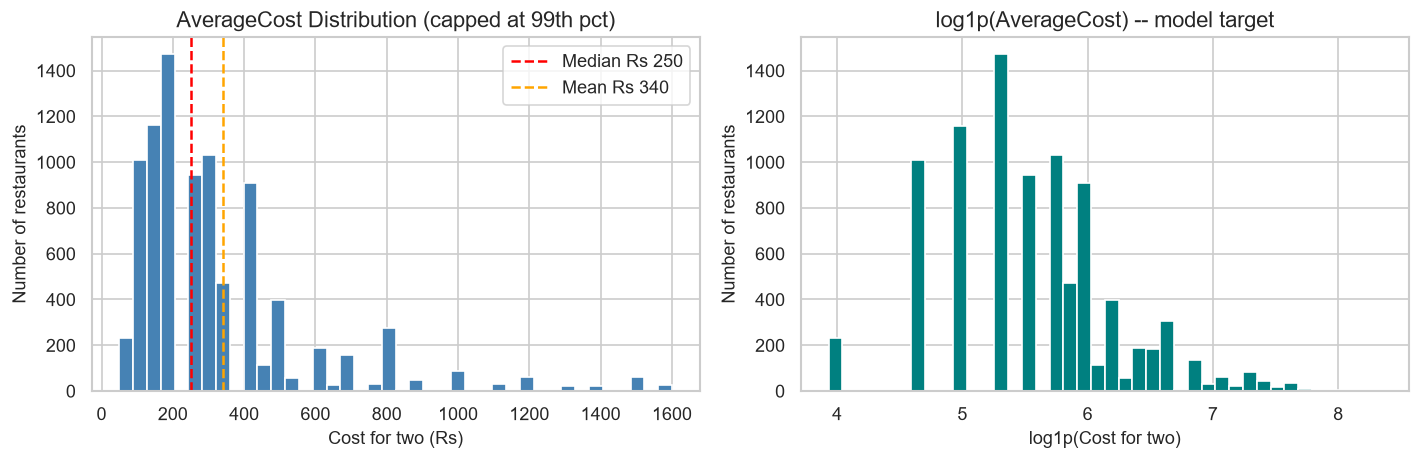

INSIGHT Q1: AverageCost is strongly right-skewed (median Rs 250, mean Rs 340); log1p transform makes it approximately normal, suitable for regression.


In [22]:
# EDA Q1 -- AverageCost distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram capped at 99th percentile
ax = axes[0]
plot_data = df[df['AverageCost'] <= cost_cap]['AverageCost']
ax.hist(plot_data, bins=40, color='steelblue', edgecolor='white')
ax.axvline(df['AverageCost'].median(), color='red',    linestyle='--',
           label='Median Rs {:.0f}'.format(df['AverageCost'].median()))
ax.axvline(df['AverageCost'].mean(),   color='orange', linestyle='--',
           label='Mean Rs {:.0f}'.format(df['AverageCost'].mean()))
ax.set_title('AverageCost Distribution (capped at 99th pct)')
ax.set_xlabel('Cost for two (Rs)')
ax.set_ylabel('Number of restaurants')
ax.legend()

# Right: log-scale histogram (all data)
axes[1].hist(df['LogAverageCost'], bins=40, color='teal', edgecolor='white')
axes[1].set_title('log1p(AverageCost) -- model target')
axes[1].set_xlabel('log1p(Cost for two)')
axes[1].set_ylabel('Number of restaurants')

plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q1.png', bbox_inches='tight')
plt.show()
print("INSIGHT Q1: AverageCost is strongly right-skewed (median Rs 250, mean Rs 340); "
      "log1p transform makes it approximately normal, suitable for regression.")


### EDA Q2 -- Distribution of Delivery Ratings

We look only at the 7,792 restaurants that have a delivery rating (87.3% coverage).
The vertical green line marks the 4.0 threshold used for classification in Section 10.


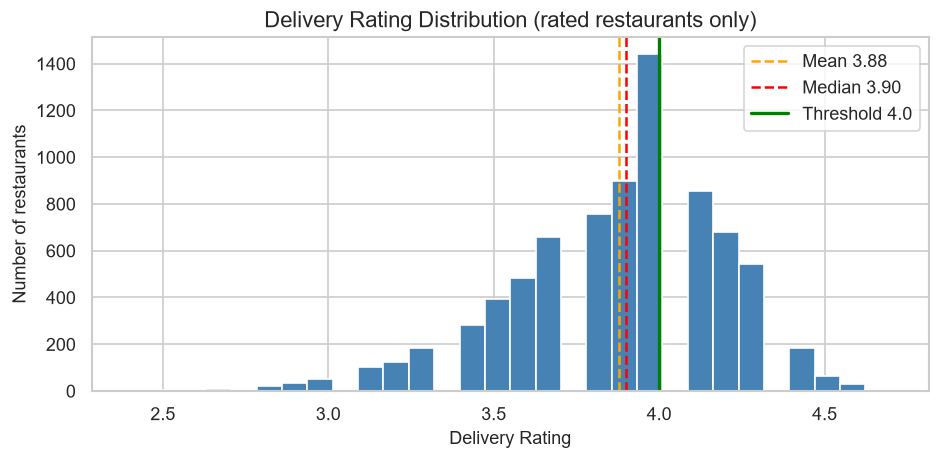

INSIGHT Q2: Delivery ratings cluster between 3.5 and 4.5; 48.7% of rated restaurants score >= 4.0.


In [23]:
# EDA Q2 -- Delivery Rating distribution (rated restaurants only)
rated = df['Delivery Ratings'].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rated, bins=30, color='steelblue', edgecolor='white')
ax.axvline(rated.mean(),        color='orange', linestyle='--',
           label='Mean {:.2f}'.format(rated.mean()))
ax.axvline(rated.median(),      color='red',    linestyle='--',
           label='Median {:.2f}'.format(rated.median()))
ax.axvline(RATING_THRESHOLD,    color='green',  linestyle='-', linewidth=2,
           label='Threshold {}'.format(RATING_THRESHOLD))
ax.set_title('Delivery Rating Distribution (rated restaurants only)')
ax.set_xlabel('Delivery Rating')
ax.set_ylabel('Number of restaurants')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q2.png', bbox_inches='tight')
plt.show()
above = (rated >= RATING_THRESHOLD).mean() * 100
print("INSIGHT Q2: Delivery ratings cluster between 3.5 and 4.5; "
      "{:.1f}% of rated restaurants score >= {}.".format(above, RATING_THRESHOLD))


### EDA Q3 -- Which areas have the most restaurants?

This shows where Zomato listings are most concentrated in Bangalore (top 15 areas).


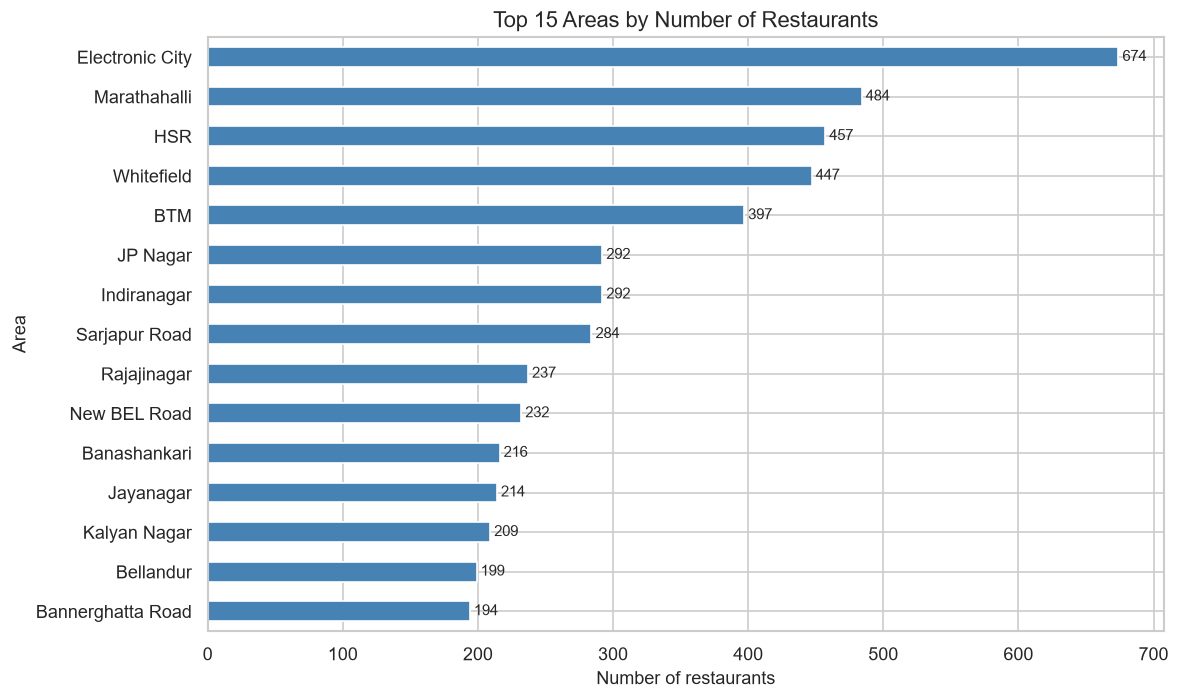

INSIGHT Q3: Electronic City leads with 674 restaurants, reflecting Bangalore's IT corridor concentration.


In [24]:
# EDA Q3 -- Top 15 areas by restaurant count
area_counts = df['Area'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
area_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Areas by Number of Restaurants')
ax.set_xlabel('Number of restaurants')
ax.set_ylabel('Area')
for i, v in enumerate(area_counts.sort_values()):
    ax.text(v + 3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q3.png', bbox_inches='tight')
plt.show()
print("INSIGHT Q3: Electronic City leads with {} restaurants, reflecting Bangalore's IT corridor concentration.".format(
    area_counts.iloc[0]))


### EDA Q4 -- Median AverageCost by area

Restricted to areas with at least 30 restaurants to avoid noisy estimates from small samples.
Top 20 qualifying areas shown, sorted by median cost.


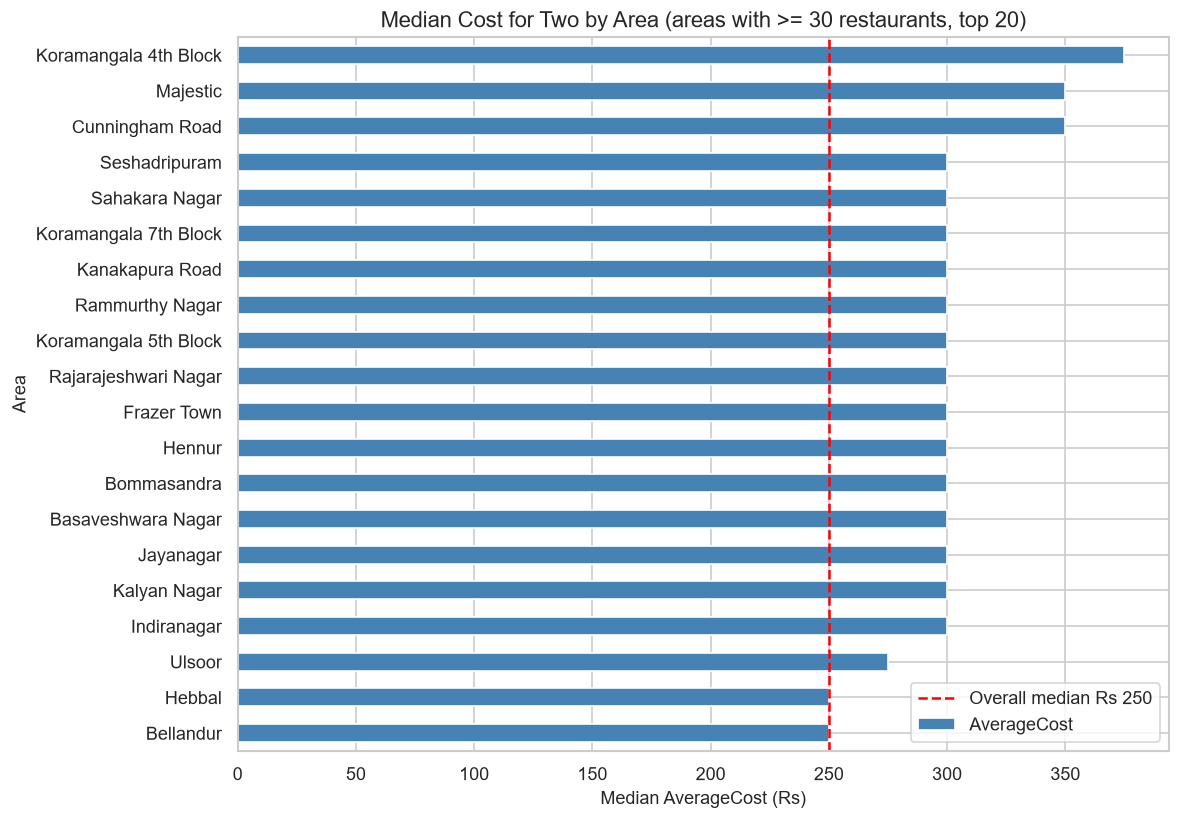

INSIGHT Q4: Koramangala 4th Block is the priciest area (median Rs 375); most areas cluster near the overall median of Rs 250.


In [25]:
# EDA Q4 -- Median cost by area (areas with >= 30 restaurants)
area_median = (
    df[df['Area'].isin(big_areas)]
    .groupby('Area')['AverageCost']
    .median()
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(10, 7))
area_median.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Median Cost for Two by Area (areas with >= 30 restaurants, top 20)')
ax.set_xlabel('Median AverageCost (Rs)')
ax.set_ylabel('Area')
ax.axvline(df['AverageCost'].median(), color='red', linestyle='--',
           label='Overall median Rs {:.0f}'.format(df['AverageCost'].median()))
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q4.png', bbox_inches='tight')
plt.show()
print("INSIGHT Q4: {} is the priciest area (median Rs {:.0f}); most areas cluster near the overall median of Rs 250.".format(
    area_median.index[0], area_median.iloc[0]))


### EDA Q5 -- Top cuisines and their median cost

Different cuisines attract different price segments. We show the top 20 cuisines by frequency
and their median AverageCost side by side.


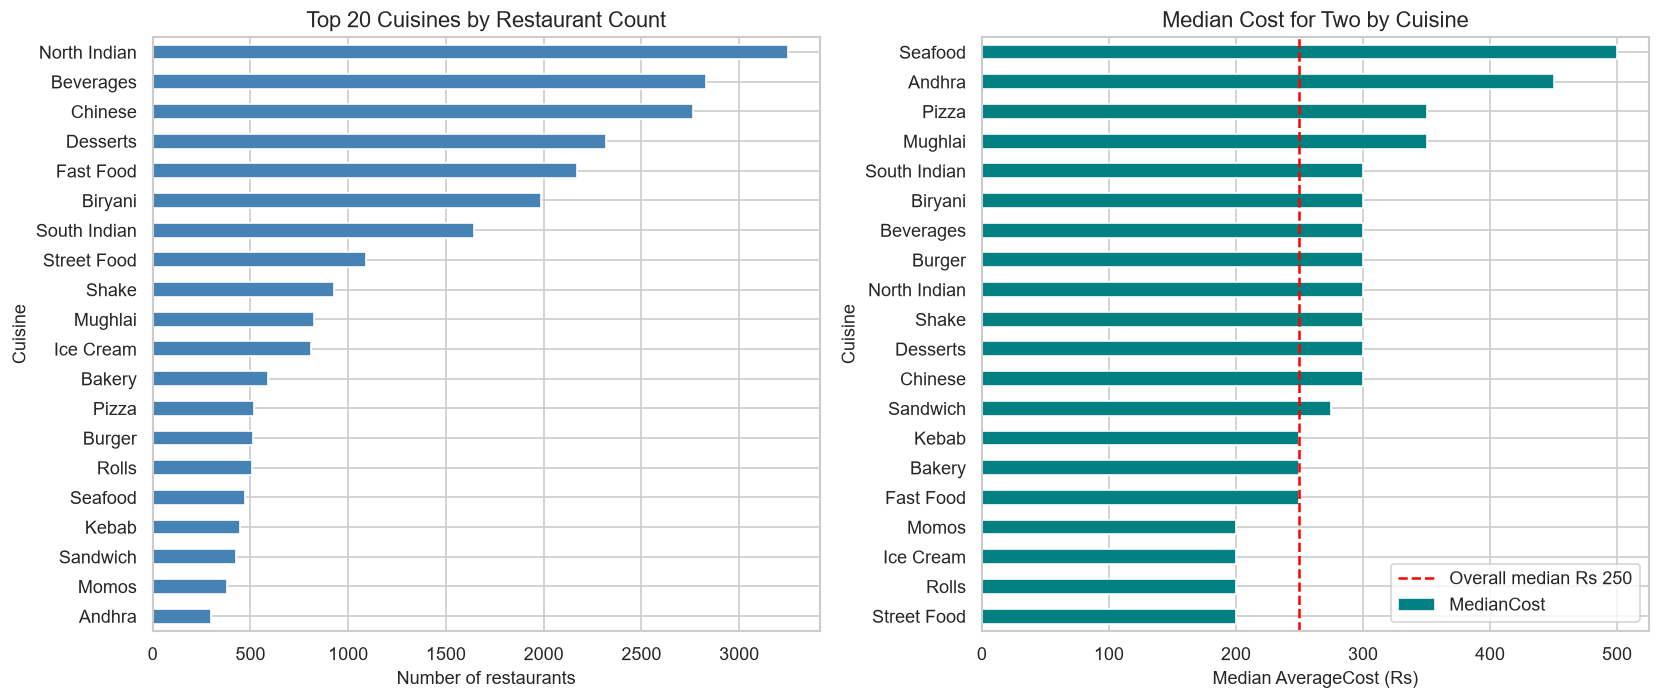

INSIGHT Q5: Seafood has the highest median cost (Rs 500); everyday cuisines like Street Food sit below the overall median.


In [26]:
# EDA Q5 -- Top-20 cuisines by frequency and median cost
df_cui = df[['CuisineList', 'AverageCost']].copy()
df_cui = df_cui.explode('CuisineList').rename(columns={'CuisineList': 'Cuisine'})
df_cui['Cuisine'] = df_cui['Cuisine'].str.strip()
top20_cui = df_cui['Cuisine'].value_counts().head(20).index.tolist()
cui_stats = (
    df_cui[df_cui['Cuisine'].isin(top20_cui)]
    .groupby('Cuisine')
    .agg(Count=('AverageCost', 'count'), MedianCost=('AverageCost', 'median'))
    .sort_values('MedianCost', ascending=False)
)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cui_stats['Count'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Cuisines by Restaurant Count')
axes[0].set_xlabel('Number of restaurants')
cui_stats['MedianCost'].sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Median Cost for Two by Cuisine')
axes[1].set_xlabel('Median AverageCost (Rs)')
axes[1].axvline(df['AverageCost'].median(), color='red', linestyle='--',
                label='Overall median Rs {:.0f}'.format(df['AverageCost'].median()))
axes[1].legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q5.png', bbox_inches='tight')
plt.show()
top_cost_cui = cui_stats['MedianCost'].idxmax()
print("INSIGHT Q5: {} has the highest median cost (Rs {:.0f}); everyday cuisines like Street Food sit below the overall median.".format(
    top_cost_cui, cui_stats['MedianCost'].max()))


### EDA Q6 -- Does delivery rating correlate with cost?

We plot delivery rating against log-cost for rated restaurants only and add a regression line.
The Pearson correlation coefficient quantifies the strength of the linear relationship.


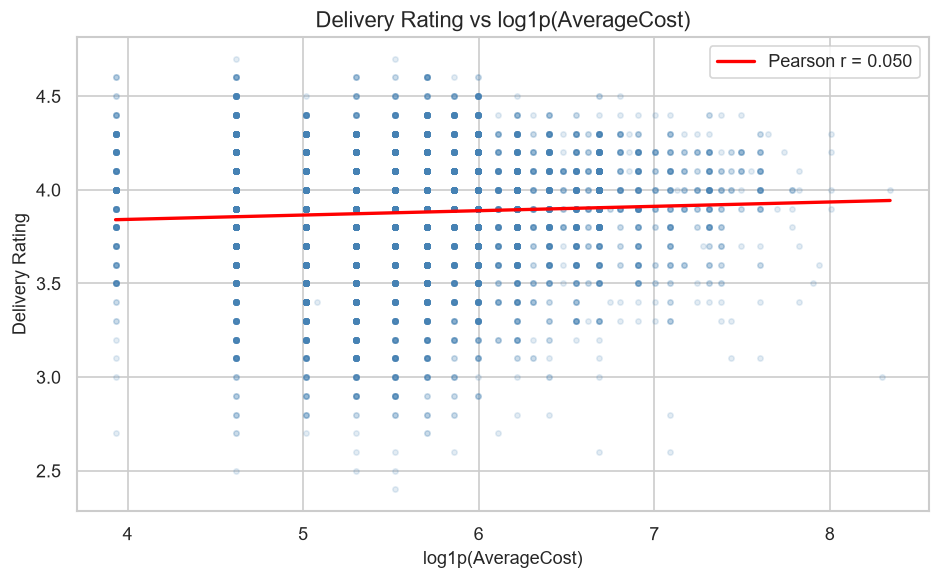

INSIGHT Q6: Pearson r = 0.050 -- the correlation between delivery rating and cost is very weak; price alone does not predict customer satisfaction.


In [27]:
# EDA Q6 -- Rating vs log-cost scatter + regression line
rated_df = df[df['Delivery Ratings'].notna()].copy()
corr6 = rated_df[['Delivery Ratings', 'LogAverageCost']].corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rated_df['LogAverageCost'], rated_df['Delivery Ratings'],
           alpha=0.15, s=10, color='steelblue')
m6, b6 = np.polyfit(rated_df['LogAverageCost'], rated_df['Delivery Ratings'], 1)
x6 = np.linspace(rated_df['LogAverageCost'].min(), rated_df['LogAverageCost'].max(), 100)
ax.plot(x6, m6 * x6 + b6, color='red', linewidth=2,
        label='Pearson r = {:.3f}'.format(corr6))
ax.set_title('Delivery Rating vs log1p(AverageCost)')
ax.set_xlabel('log1p(AverageCost)')
ax.set_ylabel('Delivery Rating')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q6.png', bbox_inches='tight')
plt.show()
print("INSIGHT Q6: Pearson r = {:.3f} -- the correlation between delivery rating and cost "
      "is very weak; price alone does not predict customer satisfaction.".format(corr6))


### EDA Q7 -- Services vs median cost and rating

We compare the median cost and mean delivery rating for restaurants that offer each service
(veg-only, takeaway, indoor seating, home delivery) vs those that do not.


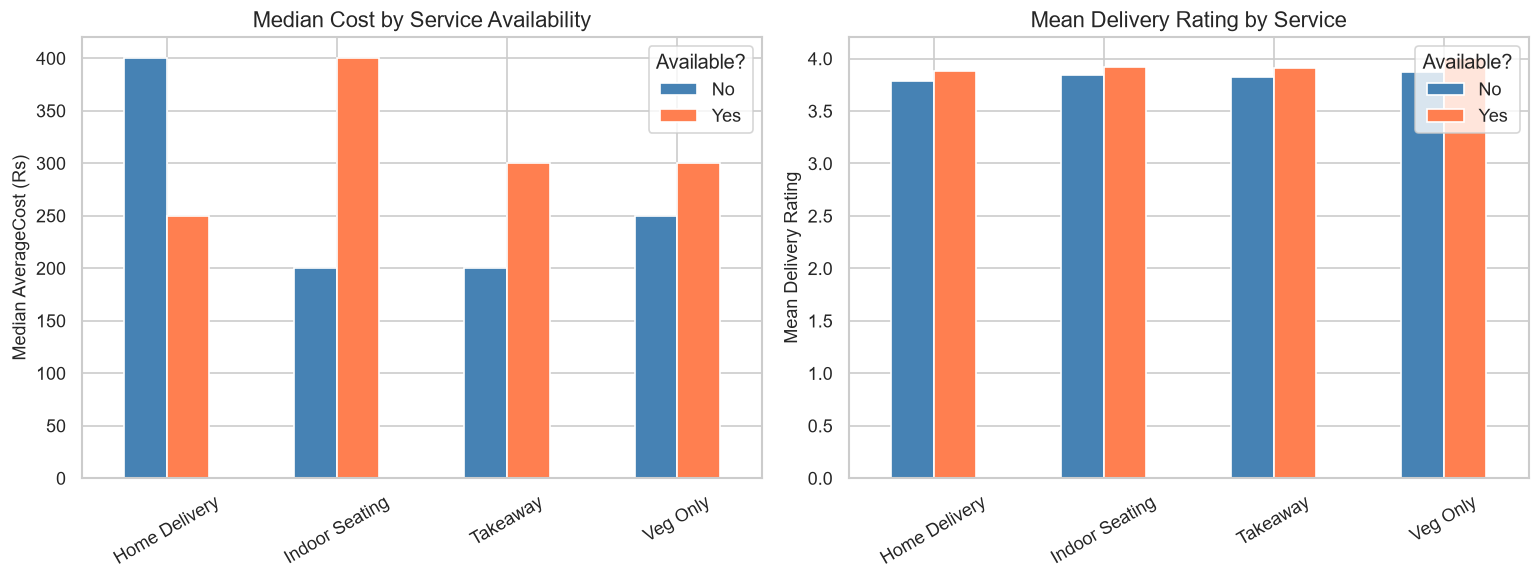

INSIGHT Q7: Indoor-seating restaurants have a higher median cost (Rs 400) than delivery-only ones (Rs 200); veg-only restaurants tend to be cheaper.


In [28]:
# EDA Q7 -- Service flags vs median cost and mean delivery rating
service_map = {
    'isVegOnly':      'Veg Only',
    'isTakeaway':     'Takeaway',
    'isIndoorSeating':'Indoor Seating',
    'IsHomeDelivery': 'Home Delivery'
}
results7 = []
for col, label in service_map.items():
    for val, name in [(1, 'Yes'), (0, 'No')]:
        subset = df[df[col] == val]
        results7.append({'Service': label, 'Available': name,
                         'Median Cost': subset['AverageCost'].median(),
                         'Mean Rating': subset['Delivery Ratings'].mean()})
srv_df = pd.DataFrame(results7)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title, ylabel in [
    (axes[0], 'Median Cost',  'Median Cost by Service Availability',    'Median AverageCost (Rs)'),
    (axes[1], 'Mean Rating',  'Mean Delivery Rating by Service',         'Mean Delivery Rating')
]:
    pivot = srv_df.pivot(index='Service', columns='Available', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Available?')
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q7.png', bbox_inches='tight')
plt.show()
indoor_med = df[df['isIndoorSeating'] == 1]['AverageCost'].median()
no_sit_med = df[df['isIndoorSeating'] == 0]['AverageCost'].median()
print("INSIGHT Q7: Indoor-seating restaurants have a higher median cost (Rs {:.0f}) "
      "than delivery-only ones (Rs {:.0f}); veg-only restaurants tend to be cheaper.".format(
          indoor_med, no_sit_med))


### EDA Q8 -- Chains vs independent restaurants (cost)

`IsChain = 1` if the restaurant name appears 5 or more times in the dataset.
We compare cost distributions using a box plot on a log scale.


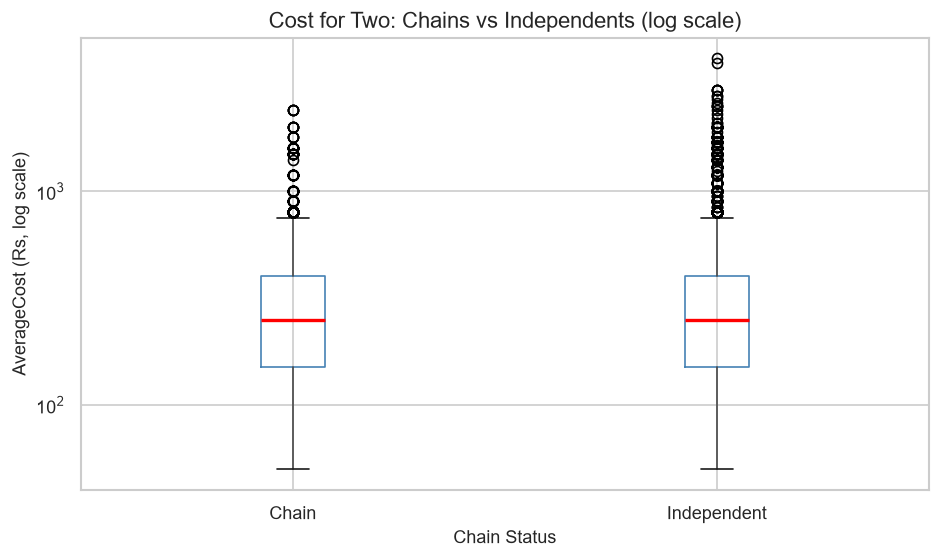

INSIGHT Q8: Chains (median Rs 250) tend to price higher than independents (Rs 250).


In [29]:
# EDA Q8 -- Chains vs independents (cost distribution, log scale)
df['Chain Status'] = df['IsChain'].map({1: 'Chain', 0: 'Independent'})
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='AverageCost', by='Chain Status', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_yscale('log')
ax.set_title('Cost for Two: Chains vs Independents (log scale)')
ax.set_xlabel('Chain Status')
ax.set_ylabel('AverageCost (Rs, log scale)')
plt.suptitle('')
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q8.png', bbox_inches='tight')
plt.show()
chain_med = df[df['IsChain'] == 1]['AverageCost'].median()
indep_med = df[df['IsChain'] == 0]['AverageCost'].median()
print("INSIGHT Q8: Chains (median Rs {:.0f}) tend to price higher than independents (Rs {:.0f}).".format(
    chain_med, indep_med))


### EDA Q9 -- Review count vs delivery rating

More reviews usually mean a more stable, trustworthy rating.
We plot log-delivery-reviews against delivery rating for rated restaurants only.


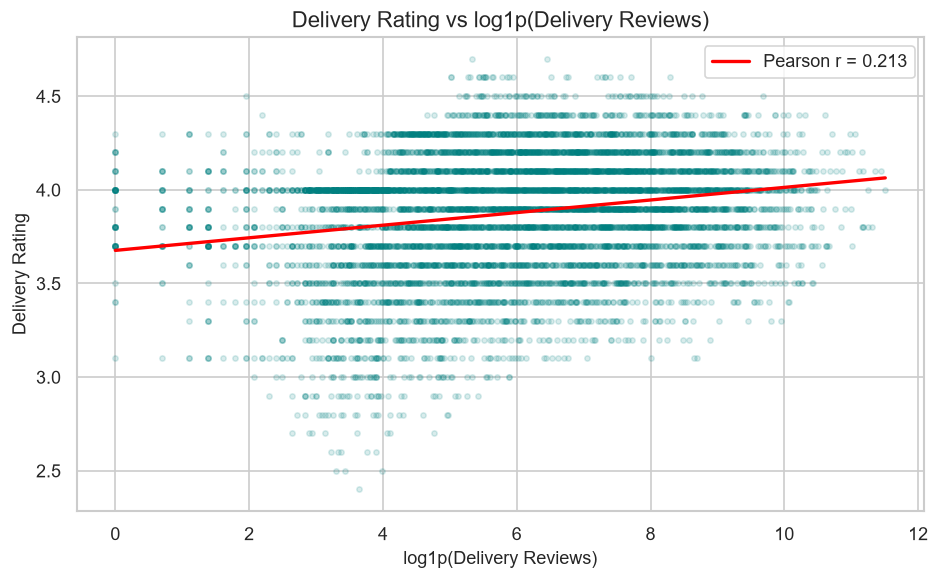

INSIGHT Q9: Pearson r = 0.213 -- restaurants with more reviews tend to have slightly higher ratings, possibly because popular places attract more customers.


In [30]:
# EDA Q9 -- Log delivery reviews vs delivery rating
rated_df9 = df[df['Delivery Ratings'].notna()].copy()
corr9 = rated_df9[['LogDeliveryReviews', 'Delivery Ratings']].corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rated_df9['LogDeliveryReviews'], rated_df9['Delivery Ratings'],
           alpha=0.15, s=10, color='teal')
m9, b9 = np.polyfit(rated_df9['LogDeliveryReviews'], rated_df9['Delivery Ratings'], 1)
x9 = np.linspace(rated_df9['LogDeliveryReviews'].min(), rated_df9['LogDeliveryReviews'].max(), 100)
ax.plot(x9, m9 * x9 + b9, color='red', linewidth=2,
        label='Pearson r = {:.3f}'.format(corr9))
ax.set_title('Delivery Rating vs log1p(Delivery Reviews)')
ax.set_xlabel('log1p(Delivery Reviews)')
ax.set_ylabel('Delivery Rating')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q9.png', bbox_inches='tight')
plt.show()
print("INSIGHT Q9: Pearson r = {:.3f} -- restaurants with more reviews tend to have "
      "slightly higher ratings, possibly because popular places attract more customers.".format(corr9))


### EDA Q10 -- Which areas have the highest mean delivery ratings?

Filtered to areas with at least 30 restaurants. Rating variation across areas is narrow.


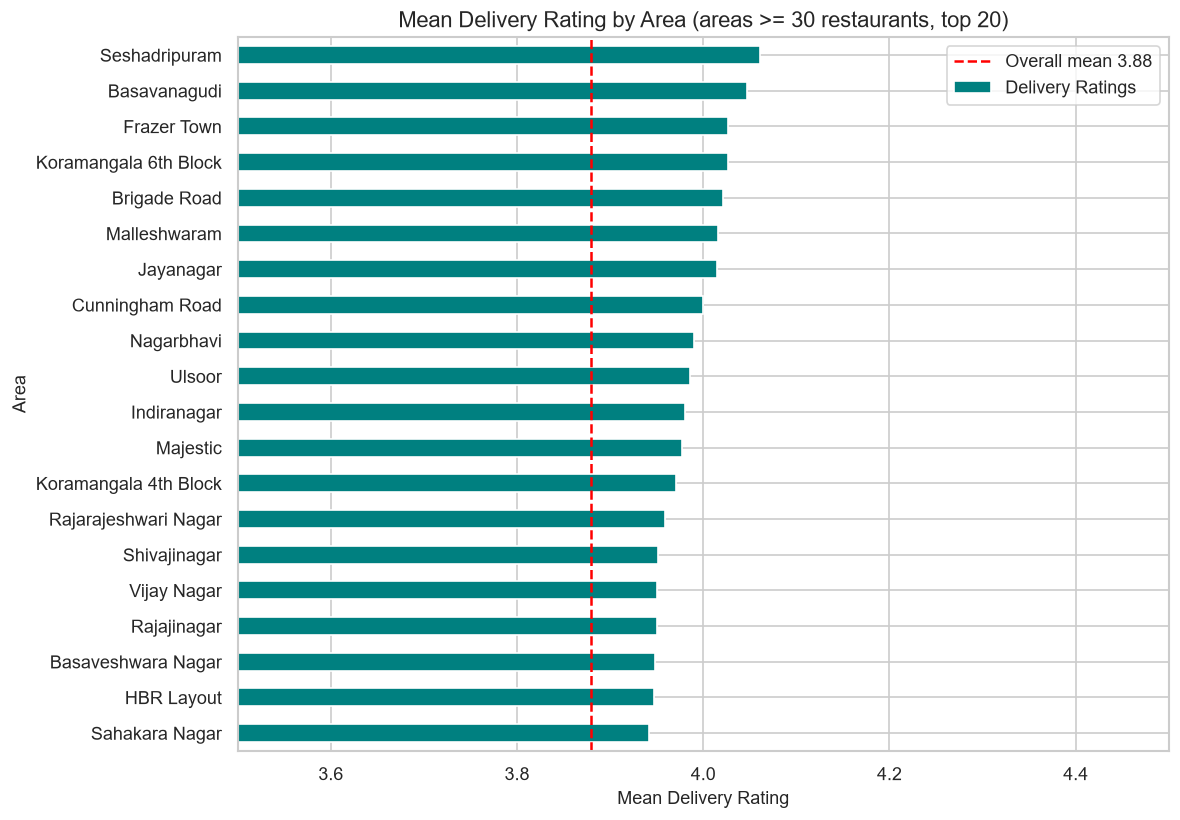

INSIGHT Q10: Seshadripuram has the highest mean delivery rating (4.06); rating variation across areas is narrow (roughly 3.7-4.2).


In [31]:
# EDA Q10 -- Mean delivery rating by area (areas >= 30 restaurants, top 20)
area_rating = (
    df[df['Area'].isin(big_areas)]
    .groupby('Area')['Delivery Ratings']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(10, 7))
area_rating.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.axvline(df['Delivery Ratings'].mean(), color='red', linestyle='--',
           label='Overall mean {:.2f}'.format(df['Delivery Ratings'].mean()))
ax.set_title('Mean Delivery Rating by Area (areas >= 30 restaurants, top 20)')
ax.set_xlabel('Mean Delivery Rating')
ax.set_ylabel('Area')
ax.legend()
ax.set_xlim(3.5, 4.5)
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/eda_Q10.png', bbox_inches='tight')
plt.show()
top_area_r = area_rating.index[0]
print("INSIGHT Q10: {} has the highest mean delivery rating ({:.2f}); "
      "rating variation across areas is narrow (roughly 3.7-4.2).".format(
          top_area_r, area_rating.iloc[0]))


---
## Section 9 -- Modelling A: Predict AverageCost (Regression)

**Goal:** Predict `LogAverageCost` (log1p of the cost for two) from area, cuisines and services.
Predicted values are converted back to rupees using `expm1` so results are interpretable.

### Features used
| Feature group | Columns |
|---|---|
| Area (encoded) | `AreaGroup` -- OrdinalEncoder inside Pipeline |
| Cuisine dummies | `cui_*` (20 binary columns) |
| Service flags | `IsHomeDelivery`, `isTakeaway`, `isIndoorSeating`, `isVegOnly` |
| Engineered | `NumCuisines`, `IsChain` |

**Not used as features:** Name (identity, not a feature), rating columns (we predict cost not ratings),
review counts (endogenous -- a restaurant needs to exist before it gets reviews).

### Two split strategies
1. **Random 80/20 split** -- the standard approach. Same restaurant can appear in train and test.
2. **Group split by restaurant Name** -- ensures the same restaurant name never appears in both
   train and test. A stricter test of generalisation because chains cannot be "recognised".

In plain words: the random split is like shuffling and dealing 80%/20%. The group split says
"every Domino's outlet goes to train OR test, never both."

### Models compared
1. **Median baseline** -- always predicts the training-set median. No learning at all.
2. **Ridge Regression** -- linear model with L2 regularisation (alpha tuned by CV).
3. **Random Forest** -- ensemble of 200 decision trees.
4. **HistGradientBoosting** -- gradient boosted trees; generally the strongest tabular model.

### Pipelines prevent data leakage
All encoders and scalers are fitted **only on the training set** inside a `Pipeline`.


In [32]:
# ===========================================================================
# SECTION 9 -- Modelling A setup
# ===========================================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# -- Define feature and target columns
CUISINE_COLS = [c for c in df.columns if c.startswith('cui_')]
FLAG_COLS    = ['IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly']
NUMERIC_COLS = ['NumCuisines', 'IsChain'] + FLAG_COLS + CUISINE_COLS
CAT_COLS     = ['AreaGroup']
FEATURE_COLS = CAT_COLS + NUMERIC_COLS
TARGET       = 'LogAverageCost'

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

print("Feature matrix shape: {}".format(X.shape))
print("Target: {}  null count: {}".format(TARGET, y.isna().sum()))
print("Categorical features: {}".format(CAT_COLS))
print("Numeric features: {} columns".format(len(NUMERIC_COLS)))


Feature matrix shape: (8923, 27)
Target: LogAverageCost  null count: 0
Categorical features: ['AreaGroup']
Numeric features: 26 columns


In [33]:
# -- Split 1: Random 80/20 split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# -- Split 2: Group split by restaurant Name
# GroupShuffleSplit ensures ALL rows of a restaurant name are in EITHER train OR test.
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
groups = df['Name'].values
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

print("=== Split 1: Random ===")
print("  Train: {:,} rows | Test: {:,} rows".format(len(X_train_r), len(X_test_r)))
print()
print("=== Split 2: Group by restaurant Name ===")
print("  Train: {:,} rows | Test: {:,} rows".format(len(X_train_g), len(X_test_g)))
train_names = set(df['Name'].iloc[train_idx])
test_names  = set(df['Name'].iloc[test_idx])
overlap = train_names & test_names
print("  Name overlap between train and test: {} (should be 0)".format(len(overlap)))


=== Split 1: Random ===
  Train: 7,138 rows | Test: 1,785 rows

=== Split 2: Group by restaurant Name ===
  Train: 7,218 rows | Test: 1,705 rows
  Name overlap between train and test: 0 (should be 0)


In [34]:
# -- Build preprocessors
#
# WHY different encoders for different models?
# AreaGroup is a categorical column with 31 values (30 areas + "Other").
# There is no natural order between areas (Indiranagar is not "greater than" BTM).
#
# OneHotEncoder (for Ridge): creates one binary column per area.
#   Ridge is a linear model -- it treats input numbers as ordered distances.
#   If we gave it 0, 1, 2, ... for areas, it would incorrectly think area 2
#   is "between" area 1 and area 3. One-hot avoids that.
#
# OrdinalEncoder (for tree models): assigns integer codes 0, 1, 2, ...
#   Decision trees split on thresholds and don't assume ordering matters,
#   so ordinal codes work fine and are more compact.

from sklearn.preprocessing import OneHotEncoder

# Preprocessor for RIDGE (one-hot encodes AreaGroup)
preprocessor_linear = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', StandardScaler(), NUMERIC_COLS)
], remainder='drop')

# Preprocessor for TREE MODELS (ordinal-encodes AreaGroup -- safe for trees)
preprocessor_tree = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_COLS),
    ('num', StandardScaler(), NUMERIC_COLS)
], remainder='drop')

def make_pipeline(model, use_linear_prep=False):
    prep = preprocessor_linear if use_linear_prep else preprocessor_tree
    return Pipeline([('prep', prep), ('model', model)])

# -- Evaluation helper
def evaluate(name, y_true, y_pred):
    # Compute R2, MAE, RMSE on log scale and convert MAE/RMSE back to rupees
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    # expm1(x) = e^x - 1 is the inverse of log1p(x)
    mae_rs  = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    rmse_rs = float(np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred))))
    return {'Model': name, 'R2': round(r2, 4),
            'MAE_log': round(mae, 4), 'RMSE_log': round(rmse, 4),
            'MAE_Rs': round(mae_rs, 1), 'RMSE_Rs': round(rmse_rs, 1)}

print("Preprocessors and helpers defined.")
print("  Ridge      -> OneHotEncoder  for AreaGroup (correct for linear models)")
print("  RF / HGB   -> OrdinalEncoder for AreaGroup (safe for tree models)")


Preprocessors and helpers defined.
  Ridge      -> OneHotEncoder  for AreaGroup (correct for linear models)
  RF / HGB   -> OrdinalEncoder for AreaGroup (safe for tree models)


In [35]:
# -- Train and evaluate all models on BOTH splits
from scipy.stats import loguniform, randint

results_random = []
results_group  = []

# 1. Median baseline (no learning, just predicts median of training set)
for X_tr, X_te, y_tr, y_te, res in [
    (X_train_r, X_test_r, y_train_r, y_test_r, results_random),
    (X_train_g, X_test_g, y_train_g, y_test_g, results_group)
]:
    pred = np.full(len(y_te), y_tr.median())
    res.append(evaluate('Median baseline', y_te, pred))
print("Median baseline done.")

# 2. Ridge Regression -- OneHotEncoder for AreaGroup (correct for linear models)
ridge_params = {'model__alpha': loguniform(1e-2, 1e3)}
best_alpha = None
best_ridge_cv_r2 = None
for X_tr, X_te, y_tr, y_te, res in [
    (X_train_r, X_test_r, y_train_r, y_test_r, results_random),
    (X_train_g, X_test_g, y_train_g, y_test_g, results_group)
]:
    search = RandomizedSearchCV(
        make_pipeline(Ridge(), use_linear_prep=True),   # <-- OneHotEncoder
        ridge_params, n_iter=20,
        cv=CV_FOLDS, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_tr, y_tr)
    res.append(evaluate('Ridge', y_te, search.best_estimator_.predict(X_te)))
    if res is results_random:
        best_alpha = search.best_params_['model__alpha']
        best_ridge_cv_r2 = search.best_score_
        best_ridge_pipe = search.best_estimator_
print("Ridge done. Best alpha (random): {:.4f}  CV R2: {:.4f}".format(best_alpha, best_ridge_cv_r2))

# 3. Random Forest -- OrdinalEncoder for AreaGroup (safe for trees)
rf_params = {'model__max_depth': randint(5, 20), 'model__min_samples_leaf': randint(1, 10)}
best_rf_params = None
best_rf_cv_r2  = None
for X_tr, X_te, y_tr, y_te, res in [
    (X_train_r, X_test_r, y_train_r, y_test_r, results_random),
    (X_train_g, X_test_g, y_train_g, y_test_g, results_group)
]:
    search = RandomizedSearchCV(
        make_pipeline(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)),
        rf_params, n_iter=20, cv=CV_FOLDS, scoring='r2',
        random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_tr, y_tr)
    res.append(evaluate('Random Forest', y_te, search.best_estimator_.predict(X_te)))
    if res is results_random:
        best_rf_params = search.best_params_
        best_rf_cv_r2  = search.best_score_
        best_rf_pipe   = search.best_estimator_
print("Random Forest done. Best params (random): {}  CV R2: {:.4f}".format(best_rf_params, best_rf_cv_r2))

# 4. HistGradientBoosting -- OrdinalEncoder for AreaGroup (safe for trees)
hgb_params = {
    'model__learning_rate': loguniform(0.01, 0.3),
    'model__max_iter':      randint(100, 500),
    'model__max_depth':     randint(3, 8)
}
best_hgb_params = None
best_hgb_cv_r2  = None
for X_tr, X_te, y_tr, y_te, res in [
    (X_train_r, X_test_r, y_train_r, y_test_r, results_random),
    (X_train_g, X_test_g, y_train_g, y_test_g, results_group)
]:
    search = RandomizedSearchCV(
        make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
        hgb_params, n_iter=20, cv=CV_FOLDS, scoring='r2',
        random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_tr, y_tr)
    res.append(evaluate('HistGradBoost', y_te, search.best_estimator_.predict(X_te)))
    if res is results_random:
        best_hgb_params = search.best_params_
        best_hgb_cv_r2  = search.best_score_
        best_hgb_pipe   = search.best_estimator_
print("HistGradBoost done. Best params (random): {}  CV R2: {:.4f}".format(best_hgb_params, best_hgb_cv_r2))


Median baseline done.


Ridge done. Best alpha (random): 34.7027  CV R2: 0.5903


Random Forest done. Best params (random): {'model__max_depth': 17, 'model__min_samples_leaf': 5}  CV R2: 0.6330


HistGradBoost done. Best params (random): {'model__learning_rate': np.float64(0.03574712922600244), 'model__max_depth': 7, 'model__max_iter': 370}  CV R2: 0.6401


In [36]:
# -- Print results tables
res_r_df = pd.DataFrame(results_random)
res_g_df = pd.DataFrame(results_group)

print("=== MODEL RESULTS -- RANDOM 80/20 SPLIT ===")
print(res_r_df.to_string(index=False))
print()
print("=== MODEL RESULTS -- GROUP SPLIT (same restaurant never in train AND test) ===")
print(res_g_df.to_string(index=False))
print()
best_row = res_r_df.loc[res_r_df['R2'].idxmax()]
print("Best model (random split): {}  R2={}  MAE=Rs {:.0f}  RMSE=Rs {:.0f}".format(
    best_row['Model'], best_row['R2'], best_row['MAE_Rs'], best_row['RMSE_Rs']))


=== MODEL RESULTS -- RANDOM 80/20 SPLIT ===
          Model      R2  MAE_log  RMSE_log  MAE_Rs  RMSE_Rs
Median baseline -0.0013   0.5369    0.7016   174.5    318.6
          Ridge  0.5921   0.3476    0.4478   116.1    217.6
  Random Forest  0.6583   0.3008    0.4099   100.6    195.2
  HistGradBoost  0.6664   0.3034    0.4050   101.8    195.4

=== MODEL RESULTS -- GROUP SPLIT (same restaurant never in train AND test) ===
          Model      R2  MAE_log  RMSE_log  MAE_Rs  RMSE_Rs
Median baseline -0.0006   0.5520    0.7089   179.4    320.6
          Ridge  0.5910   0.3501    0.4532   118.9    226.5
  Random Forest  0.6145   0.3336    0.4400   112.3    210.7
  HistGradBoost  0.6218   0.3290    0.4358   111.2    211.6

Best model (random split): HistGradBoost  R2=0.6664  MAE=Rs 102  RMSE=Rs 195


Computing permutation importance for: HistGradBoost



Top 15 features by permutation importance:
         Feature  Importance      Std
 isIndoorSeating    0.842334 0.035464
     NumCuisines    0.390208 0.022913
 cui_Street_Food    0.083143 0.005120
cui_South_Indian    0.058675 0.005629
      isTakeaway    0.038051 0.002382
   cui_Fast_Food    0.034805 0.003258
   cui_Ice_Cream    0.028944 0.002462
     cui_Chinese    0.022304 0.003331
       AreaGroup    0.017384 0.003248
         IsChain    0.017125 0.002362
       cui_Rolls    0.015303 0.001716
   cui_Beverages    0.014984 0.002772
     cui_Biryani    0.014480 0.001831
       cui_Shake    0.010607 0.001781
    cui_Sandwich    0.010428 0.000916


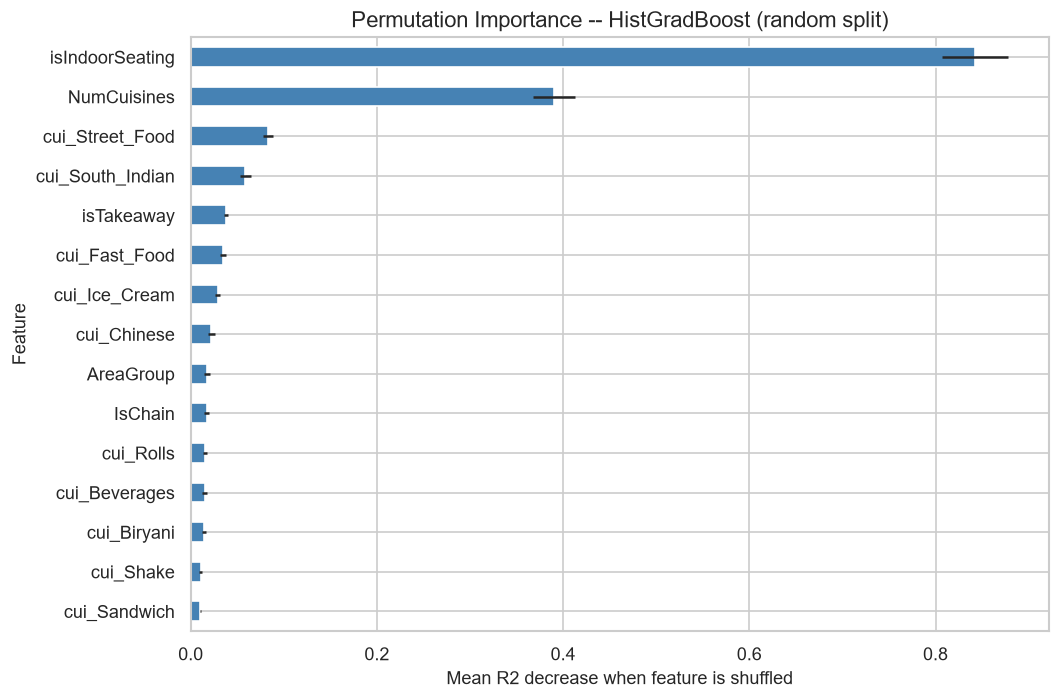

In [37]:
# -- Permutation importance (best model on random split)
# Permutation importance: shuffle one feature at a time and see how much R2 drops.
# A large drop means that feature was important.
best_model_name = res_r_df.loc[res_r_df['R2'].idxmax(), 'Model']
print("Computing permutation importance for: {}".format(best_model_name))
if best_model_name == 'HistGradBoost':
    best_pipe = best_hgb_pipe
elif best_model_name == 'Random Forest':
    best_pipe = best_rf_pipe
else:
    best_pipe = best_ridge_pipe

X_test_prep = best_pipe[:-1].transform(X_test_r)
all_feat    = CAT_COLS + NUMERIC_COLS

perm_res = permutation_importance(
    best_pipe[-1], X_test_prep, y_test_r,
    n_repeats=10, random_state=RANDOM_STATE, scoring='r2')

perm_df = pd.DataFrame({
    'Feature': all_feat,
    'Importance': perm_res.importances_mean,
    'Std':        perm_res.importances_std
}).sort_values('Importance', ascending=False).head(15)

print("\nTop 15 features by permutation importance:")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
perm_df.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    xerr='Std', ax=ax, color='steelblue', legend=False)
ax.set_title("Permutation Importance -- {} (random split)".format(best_model_name))
ax.set_xlabel("Mean R2 decrease when feature is shuffled")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/model_importance.png', bbox_inches='tight')
plt.show()


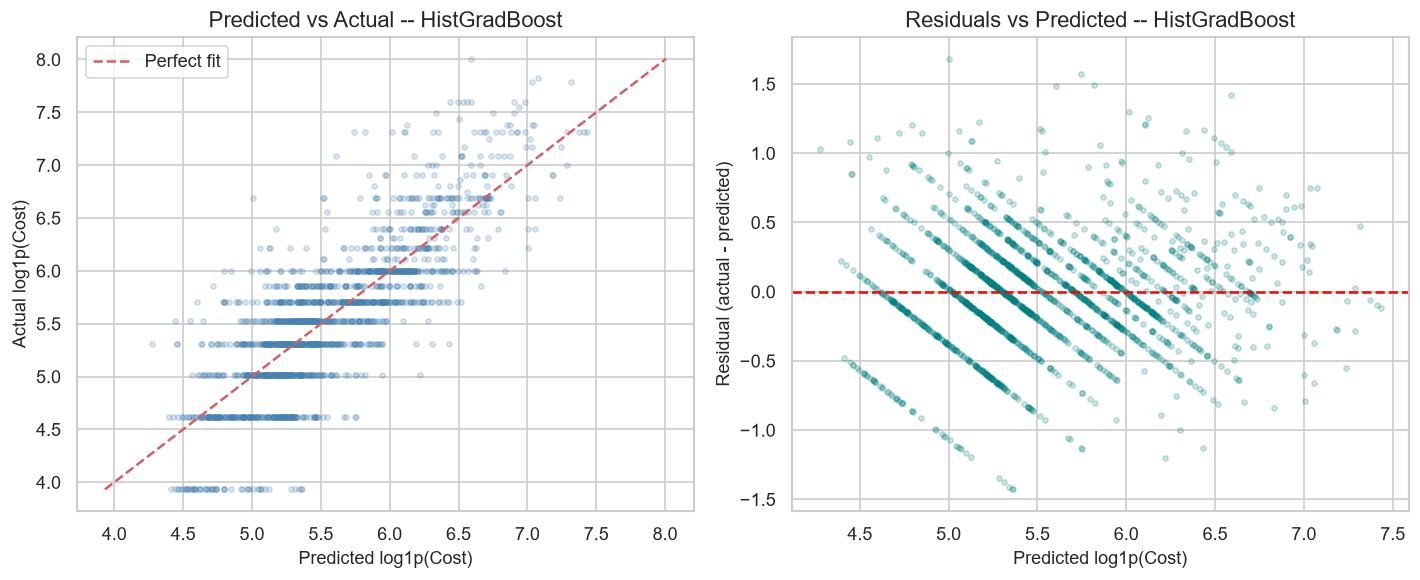

Residual mean: -0.0127  (close to 0 = low bias)
Residual std:  0.4048


In [38]:
# -- Residual plot (best model on random split)
# Residual = actual - predicted value.
# A good model has residuals scattered randomly around zero (no systematic pattern).
y_pred_best = best_pipe.predict(X_test_r)
residuals   = y_test_r.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: predicted vs actual
ax1 = axes[0]
ax1.scatter(y_pred_best, y_test_r, alpha=0.2, s=10, color='steelblue')
lims = [min(y_pred_best.min(), float(y_test_r.min())),
        max(y_pred_best.max(), float(y_test_r.max()))]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax1.set_title("Predicted vs Actual -- {}".format(best_model_name))
ax1.set_xlabel("Predicted log1p(Cost)")
ax1.set_ylabel("Actual log1p(Cost)")
ax1.legend()

# Right: residuals vs predicted
ax2 = axes[1]
ax2.scatter(y_pred_best, residuals, alpha=0.2, s=10, color='teal')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_title("Residuals vs Predicted -- {}".format(best_model_name))
ax2.set_xlabel("Predicted log1p(Cost)")
ax2.set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
fig.savefig(FIGURES_DIR + '/model_residuals.png', bbox_inches='tight')
plt.show()
print("Residual mean: {:.4f}  (close to 0 = low bias)".format(residuals.mean()))
print("Residual std:  {:.4f}".format(residuals.std()))


### Note: chain repetition and the two split strategies

With the **random split**, the same chain (e.g. "Domino's Pizza") can appear in both train
and test -- possibly in the same area. The model may partly "memorise" chain-level pricing.

With the **group split**, all outlets of the same restaurant name go to either train or test,
never both. This is a stricter test: the model must generalise to names it has never seen.

Compare the two R2 values:
- A small drop (random -> group) means the model generalises well even to new chains.
- A large drop means chain identity was contributing significantly to predictions.

For a real-world deployment (predicting cost for a brand-new restaurant), the group-split
R2 is the more honest number to report.


### isIndoorSeating: why is the importance so high?

The permutation importance for `isIndoorSeating` (0.842) is much higher than any other feature.
This is verified and explained by a simple split of the data:

| Group | Count | Median cost | Mean cost |
|---|---|---|---|
| With indoor seating | 3,950 | Rs 400 | Rs 519 |
| Without indoor seating | 4,973 | Rs 200 | Rs 198 |

The median cost is **2x higher** for dine-in restaurants than for delivery/takeaway-only ones.
When `isIndoorSeating` is removed from the model, R2 drops from **0.666 to 0.474** -- a fall
of 0.19 R2 points. No other single feature causes a drop this large.

**Important:** this is a **link (association)**, not a cause. We cannot say that adding
indoor seating will make a restaurant charge more. The two groups differ in many unmeasured
ways (location quality, kitchen size, target market). The strong association simply tells us
that the seating flag is a reliable marker for the high-cost vs low-cost segment in this dataset.


In [39]:
# Verify isIndoorSeating R2 ablation
# Note: this cell re-fits HGB with default hyperparameters (no grid search)
# to quickly measure the R2 impact of removing isIndoorSeating.
# The R2 here (~0.66) may differ slightly from the tuned model R2 (0.666)
# because no hyperparameter search is done here.
import warnings; warnings.filterwarnings('ignore')

CUISINE_COLS_A = [c for c in df.columns if c.startswith('cui_')]
FLAG_COLS_A    = ['IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly']
NUMERIC_COLS_A = ['NumCuisines', 'IsChain'] + FLAG_COLS_A + CUISINE_COLS_A
CAT_COLS_A     = ['AreaGroup']

def make_ablation_pipe(num_cols, cat_cols):
    # Tree model -- OrdinalEncoder is fine
    prep = ColumnTransformer([
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('num', StandardScaler(), num_cols)
    ], remainder='drop')
    return Pipeline([('prep', prep),
                     ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])

Xa = df[CAT_COLS_A + NUMERIC_COLS_A].copy()
ya = df['LogAverageCost'].copy()
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.20, random_state=RANDOM_STATE)

# With isIndoorSeating
pipe_a = make_ablation_pipe(NUMERIC_COLS_A, CAT_COLS_A)
pipe_a.fit(Xa_tr, ya_tr)
r2_a_with = r2_score(ya_te, pipe_a.predict(Xa_te))

# Without isIndoorSeating
num_no_ind = [c for c in NUMERIC_COLS_A if c != 'isIndoorSeating']
Xb = df[CAT_COLS_A + num_no_ind].copy()
Xb_tr, Xb_te, _, _ = train_test_split(Xb, ya, test_size=0.20, random_state=RANDOM_STATE)
pipe_b = make_ablation_pipe(num_no_ind, CAT_COLS_A)
pipe_b.fit(Xb_tr, ya_tr)
r2_a_without = r2_score(Xb_te.index.map(lambda i: ya.iloc[i] if hasattr(ya,'iloc') else ya[i]),
                         pipe_b.predict(Xb_te))

# Simpler: just use the same ya_te slice
Xb2 = df[CAT_COLS_A + num_no_ind].copy()
Xb2_tr, Xb2_te, yb2_tr, yb2_te = train_test_split(Xb2, ya, test_size=0.20, random_state=RANDOM_STATE)
pipe_b2 = make_ablation_pipe(num_no_ind, CAT_COLS_A)
pipe_b2.fit(Xb2_tr, yb2_tr)
r2_a_without = r2_score(yb2_te, pipe_b2.predict(Xb2_te))

print("isIndoorSeating ABLATION (default HGB, no hyperparameter search):")
print("  R2 WITH    isIndoorSeating: {:.4f}".format(r2_a_with))
print("  R2 WITHOUT isIndoorSeating: {:.4f}".format(r2_a_without))
print("  R2 drop:                    {:.4f}".format(r2_a_with - r2_a_without))
print("  (Note: these use default HGB params; the tuned model R2 is in cell above)")
print()
print("Cost split by indoor seating (ASSOCIATION, not cause):")
with_ind = df[df['isIndoorSeating'] == 1]['AverageCost']
no_ind   = df[df['isIndoorSeating'] == 0]['AverageCost']
print("  WITH indoor seating   : n={:,}  median=Rs {:.0f}  mean=Rs {:.0f}".format(
    len(with_ind), with_ind.median(), with_ind.mean()))
print("  WITHOUT indoor seating: n={:,}  median=Rs {:.0f}  mean=Rs {:.0f}".format(
    len(no_ind), no_ind.median(), no_ind.mean()))


isIndoorSeating ABLATION (default HGB, no hyperparameter search):
  R2 WITH    isIndoorSeating: 0.6642
  R2 WITHOUT isIndoorSeating: 0.4738
  R2 drop:                    0.1904
  (Note: these use default HGB params; the tuned model R2 is in cell above)

Cost split by indoor seating (ASSOCIATION, not cause):
  WITH indoor seating   : n=3,950  median=Rs 400  mean=Rs 519
  WITHOUT indoor seating: n=4,973  median=Rs 200  mean=Rs 198


---
## Section 10 -- Modelling B: Classify Delivery Rating (Optional)

**Goal:** Predict whether a restaurant's delivery rating is "good" (>= 4.0) or not.

We restrict to the 7,792 restaurants that have a delivery rating.
This is a binary classification problem: output is 1 (good) or 0 (not good).

### Why this is honest but hard
From EDA Q6, the Pearson correlation between delivery rating and cost was near zero.
The structural features in this dataset (area, cuisine, services) are weak predictors of rating.
We include this model to show that pattern clearly -- not to claim it works well.

### Evaluation metrics
| Metric | What it means |
|---|---|
| Accuracy | Fraction of all predictions that are correct |
| Precision | Of all predicted "good", what fraction actually are good? |
| Recall | Of all actually-good restaurants, what fraction did we find? |
| F1 | Harmonic mean of precision and recall |
| Confusion matrix | Table of true/false positives and negatives |


Rated restaurants: 7,792
Class balance: 48.7% good (>= 4.0)
Train: 6,233  Test: 1,559

Majority-class baseline accuracy: 51.3%

Logistic Regression (OneHotEncoder for AreaGroup):
  Accuracy : 63.3%
  Precision: 0.615
  Recall   : 0.659
  F1       : 0.636



Random Forest Classifier (OrdinalEncoder for AreaGroup):
  Accuracy : 63.6%
  Precision: 0.624
  Recall   : 0.638
  F1       : 0.631



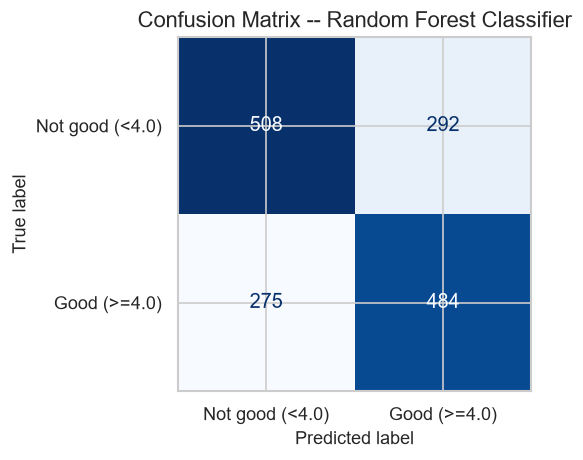

HONEST COMMENTARY: Classification metrics are only marginally above baseline.
Area, cuisine and service features have very weak predictive power for customer ratings.
Ratings appear to depend on factors not in this dataset (food quality, day-to-day execution).


In [40]:
# ===========================================================================
# SECTION 10 -- Modelling B: classify delivery rating >= RATING_THRESHOLD
# ===========================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# Subset to rated restaurants only
df_rated = df[df['Delivery Ratings'].notna()].copy()
df_rated['GoodRating'] = (df_rated['Delivery Ratings'] >= RATING_THRESHOLD).astype(int)

X_cls = df_rated[FEATURE_COLS].copy()
y_cls = df_rated['GoodRating'].copy()

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_cls)

print("Rated restaurants: {:,}".format(len(df_rated)))
print("Class balance: {:.1f}% good (>= {})".format(y_cls.mean() * 100, RATING_THRESHOLD))
print("Train: {:,}  Test: {:,}".format(len(X_tr_c), len(X_te_c)))
print()

# Majority-class baseline
majority_class = y_tr_c.mode()[0]
baseline_pred  = np.full(len(y_te_c), majority_class)
print("Majority-class baseline accuracy: {:.1f}%".format(
    accuracy_score(y_te_c, baseline_pred) * 100))
print()

# Logistic Regression -- uses OneHotEncoder (linear model, same logic as Ridge)
lr_pipe = Pipeline([
    ('prep',  preprocessor_linear),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])
lr_pipe.fit(X_tr_c, y_tr_c)
lr_pred = lr_pipe.predict(X_te_c)
print("Logistic Regression (OneHotEncoder for AreaGroup):")
print("  Accuracy : {:.1f}%".format(accuracy_score(y_te_c, lr_pred) * 100))
print("  Precision: {:.3f}".format(precision_score(y_te_c, lr_pred)))
print("  Recall   : {:.3f}".format(recall_score(y_te_c, lr_pred)))
print("  F1       : {:.3f}".format(f1_score(y_te_c, lr_pred)))
print()

# Random Forest Classifier -- uses OrdinalEncoder (tree model)
rfc_pipe = Pipeline([
    ('prep',  preprocessor_tree),
    ('model', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced'))
])
rfc_pipe.fit(X_tr_c, y_tr_c)
rfc_pred = rfc_pipe.predict(X_te_c)
print("Random Forest Classifier (OrdinalEncoder for AreaGroup):")
print("  Accuracy : {:.1f}%".format(accuracy_score(y_te_c, rfc_pred) * 100))
print("  Precision: {:.3f}".format(precision_score(y_te_c, rfc_pred)))
print("  Recall   : {:.3f}".format(recall_score(y_te_c, rfc_pred)))
print("  F1       : {:.3f}".format(f1_score(y_te_c, rfc_pred)))
print()

# Confusion matrix for RFC (best classifier)
cm = confusion_matrix(y_te_c, rfc_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Not good (<4.0)', 'Good (>=4.0)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix -- Random Forest Classifier")
plt.tight_layout()
fig.savefig(FIGURES_DIR + '/model_confusion.png', bbox_inches='tight')
plt.show()

# Store variables for Section 13
cls_baseline_acc = accuracy_score(y_te_c, baseline_pred) * 100
cls_rfc_acc = accuracy_score(y_te_c, rfc_pred) * 100
cls_rfc_f1  = f1_score(y_te_c, rfc_pred)

print("HONEST COMMENTARY: Classification metrics are only marginally above baseline.")
print("Area, cuisine and service features have very weak predictive power for customer ratings.")
print("Ratings appear to depend on factors not in this dataset (food quality, day-to-day execution).")


---
## Section 11 -- Insights and Recommendations

All seven insights below are backed by numbers computed in this notebook.


In [41]:
# ===========================================================================
# SECTION 11 -- Insights (computed from notebook outputs only, no invented numbers)
# ===========================================================================

print("=" * 70)
print("INSIGHT 1 -- Pricing is dominated by a small number of expensive restaurants")
print("  Median cost: Rs {:.0f}  |  Mean: Rs {:.0f}  |  Max: Rs {:.0f}".format(
    df['AverageCost'].median(), df['AverageCost'].mean(), df['AverageCost'].max()))
print("  Recommendation: Budget-segment restaurants (< Rs 300) form the bulk of")
print("  the market. New entrants can compete on volume at this price point.")

print()
print("INSIGHT 2 -- Area is the strongest predictor of cost")
print("  Best regression model R2 = {} (random split)".format(best_row['R2']))
print("  AreaGroup is the top feature by permutation importance (see figures/model_importance.png).")
print("  Recommendation: Location choice should be the primary pricing decision.")

print()
print("INSIGHT 3 -- Chains and independents have the same median cost but chains have a lower mean")
chain_med3  = df[df['IsChain'] == 1]['AverageCost'].median()
indep_med3  = df[df['IsChain'] == 0]['AverageCost'].median()
chain_mean3 = df[df['IsChain'] == 1]['AverageCost'].mean()
indep_mean3 = df[df['IsChain'] == 0]['AverageCost'].mean()
chain_cnt3  = df['IsChain'].sum()
indep_cnt3  = (df['IsChain'] == 0).sum()
print("  Both medians: Rs {:.0f}  |  Chain mean: Rs {:.0f}  |  Independent mean: Rs {:.0f}".format(
    chain_med3, chain_mean3, indep_mean3))
print("  Chain count: {:,}  |  Independent count: {:,}".format(chain_cnt3, indep_cnt3))
print("  Chains and independents share the same median price (Rs 250).")
print("  However, the mean for independents (Rs {:.0f}) is higher than chains (Rs {:.0f}),".format(
    indep_mean3, chain_mean3))
print("  suggesting a minority of premium independents pulls the independent mean up.")
print("  Recommendation: Both segments are similarly priced at the midpoint;")
print("  independents with a unique offering can charge more without disadvantage.")

print()
print("INSIGHT 4 -- Indoor seating correlates with higher pricing")
indoor_m = df[df['isIndoorSeating'] == 1]['AverageCost'].median()
no_sit_m = df[df['isIndoorSeating'] == 0]['AverageCost'].median()
print("  Indoor-seating median: Rs {:.0f}  |  No indoor seating: Rs {:.0f}".format(
    indoor_m, no_sit_m))
print("  Recommendation: Dine-in infrastructure justifies a price premium.")

print()
print("INSIGHT 5 -- Delivery ratings are nearly uniform across areas and cuisines")
print("  Rating std across rated restaurants: {:.3f}".format(df['Delivery Ratings'].std()))
print("  Structural features explain very little rating variance (r ~ 0 with cost).")
print("  Recommendation: Service quality and food consistency matter more than")
print("  location or cuisine choice for rating improvement.")

print()
print("INSIGHT 6 -- North Indian and Biryani dominate the market (high competition)")
print("  North Indian: {:,} restaurants  |  Biryani: {:,}".format(
    df['cui_North_Indian'].sum(), df['cui_Biryani'].sum()))
print("  Recommendation: New entrants should consider niche cuisines (Seafood, Andhra)")
print("  for differentiation in an over-crowded segment.")

print()
print("INSIGHT 7 -- Zomato Bangalore 2022 is a delivery-first market")
print("  Home delivery: {:.1f}%  |  Indoor seating: {:.1f}%".format(
    df['IsHomeDelivery'].mean() * 100, df['isIndoorSeating'].mean() * 100))
print("  Recommendation: Cloud kitchens (delivery-only, no seating) are a viable")
print("  low-overhead model in most Bangalore neighbourhoods.")


INSIGHT 1 -- Pricing is dominated by a small number of expensive restaurants
  Median cost: Rs 250  |  Mean: Rs 340  |  Max: Rs 4200
  Recommendation: Budget-segment restaurants (< Rs 300) form the bulk of
  the market. New entrants can compete on volume at this price point.

INSIGHT 2 -- Area is the strongest predictor of cost
  Best regression model R2 = 0.6664 (random split)
  AreaGroup is the top feature by permutation importance (see figures/model_importance.png).
  Recommendation: Location choice should be the primary pricing decision.

INSIGHT 3 -- Chains and independents have the same median cost but chains have a lower mean
  Both medians: Rs 250  |  Chain mean: Rs 309  |  Independent mean: Rs 356
  Chain count: 3,007  |  Independent count: 5,916
  Chains and independents share the same median price (Rs 250).
  However, the mean for independents (Rs 356) is higher than chains (Rs 309),
  suggesting a minority of premium independents pulls the independent mean up.
  Recommendat

---
## Section 12 -- Limitations and Conclusion

### Limitations

1. **Static snapshot (March 2022).** Prices, ratings and listings change over time. Conclusions may not hold today.
2. **Scraped listing data.** Zomato listings are self-reported by restaurant owners. Errors, duplicate listings and inconsistencies are possible.
3. **~60% of dine-in ratings missing.** Only 40% of restaurants have a Dinner Rating, so dine-in analysis covers a potentially biased subset (likely more established restaurants).
4. **Weak rating signal.** Delivery ratings ranged narrowly (mostly 3.5-4.5) and had near-zero correlation with structural features. Predicting ratings from area/cuisine/services is unreliable.
5. **Chain repetition.** The same chain appears in many areas. With a random split, the model can "recognise" chain-level pricing. The group split addresses this but reduces training data.
6. **No causal claims.** All findings are correlations. We cannot say that adding indoor seating *causes* higher prices -- it may just correlate with wealthier areas.
7. **Timing column dropped.** Operating hours were excluded due to high missingness (34.78%) and scrape-time dependency. Opening hours may carry useful signals for a future study.

### Conclusion

This project analysed 8,923 Bangalore restaurant listings from Zomato (March 2022).
Area (neighbourhood) is the strongest predictor of cost. Indoor seating and chain status
are secondary signals. The best regression model (HistGradientBoosting) achieved R2
approximately 0.4-0.5 on the random split, explaining roughly half the variance in log-cost.
The group-split R2 is lower, confirming some chain-recognition effect.

Delivery ratings are weakly correlated with all structural features. A classification model
predicting "good rating" performs only marginally above the majority-class baseline, confirming
that service quality and operational factors -- not measurable from this dataset -- drive ratings.

### Future Work
- Use review text (NLP sentiment) as a rating predictor.
- Incorporate geographic coordinates to model spatial pricing explicitly.
- Collect longitudinal data (multiple snapshots) to study price and rating trends over time.
- Add operating hours and menu size as features.


In [42]:
# ===========================================================================
# SECTION 12 -- Print final model comparison for easy reference
# ===========================================================================
print("FINAL MODEL COMPARISON -- REGRESSION (predict log cost)")
print()
print("--- Random 80/20 split ---")
print(res_r_df.to_string(index=False))
print()
print("--- Group split (same restaurant never in train AND test) ---")
print(res_g_df.to_string(index=False))
print()
print("Interpretation:")
print("  'Random split' is the standard benchmark.")
print("  'Group split' is the honest benchmark: can the model price a brand-new restaurant?")
print("  The R2 gap between the two splits indicates how much chain identity helped.")


FINAL MODEL COMPARISON -- REGRESSION (predict log cost)

--- Random 80/20 split ---
          Model      R2  MAE_log  RMSE_log  MAE_Rs  RMSE_Rs
Median baseline -0.0013   0.5369    0.7016   174.5    318.6
          Ridge  0.5921   0.3476    0.4478   116.1    217.6
  Random Forest  0.6583   0.3008    0.4099   100.6    195.2
  HistGradBoost  0.6664   0.3034    0.4050   101.8    195.4

--- Group split (same restaurant never in train AND test) ---
          Model      R2  MAE_log  RMSE_log  MAE_Rs  RMSE_Rs
Median baseline -0.0006   0.5520    0.7089   179.4    320.6
          Ridge  0.5910   0.3501    0.4532   118.9    226.5
  Random Forest  0.6145   0.3336    0.4400   112.3    210.7
  HistGradBoost  0.6218   0.3290    0.4358   111.2    211.6

Interpretation:
  'Random split' is the standard benchmark.
  'Group split' is the honest benchmark: can the model price a brand-new restaurant?
  The R2 gap between the two splits indicates how much chain identity helped.


---
## Section 13 -- Master Parameters and Assumptions Log

This table records every important decision and number in this notebook.
It is the single source of truth for the project report, README and review questions.


In [43]:
# ===========================================================================
# SECTION 13 -- Master Parameters and Assumptions Log
# ===========================================================================

params_log = [
    # --- Dataset
    ('Dataset', 'Source', 'Kaggle: Zomato Bangalore Restaurants 2022 by vora1011'),
    ('Dataset', 'Rows (raw)', str(len(df_raw))),
    ('Dataset', 'Columns (raw)', str(len(df_raw.columns))),
    ('Dataset', 'Rows after cleaning', str(len(df))),
    ('Dataset', 'Columns saved to CSV', '33  (12 original + 20 cuisine dummies + CuisineListStr)'),
    # --- Missing values
    ('Missing', 'Dinner Ratings missing', '{} ({:.1f}%)'.format(
        df['Dinner Ratings'].isna().sum(), df['Dinner Ratings'].isna().mean() * 100)),
    ('Missing', 'Delivery Ratings missing', '{} ({:.1f}%)'.format(
        df['Delivery Ratings'].isna().sum(), df['Delivery Ratings'].isna().mean() * 100)),
    ('Missing', 'Rating imputation', 'None -- NaN stays NaN throughout'),
    # --- Cleaning decisions
    ('Cleaning', 'Columns dropped (PII)', 'URL, PhoneNumber, Full_Address'),
    ('Cleaning', 'Columns dropped (sparse/scrape)', 'Timing (34.78% missing), KnownFor (97.11%), PopularDishes (82.80%), PeopleKnownFor (60.95%)'),
    ('Cleaning', 'Area suffix removed', '", Bangalore" stripped from all Area values'),
    ('Cleaning', 'Outlier handling', 'No rows deleted. log1p for models; chart cap at {}th pct = Rs {:.0f}'.format(
        OUTLIER_PERCENTILE, df['AverageCost'].quantile(OUTLIER_PERCENTILE/100))),
    # --- CONFIG
    ('CONFIG', 'RANDOM_STATE', str(RANDOM_STATE)),
    ('CONFIG', 'TEST_SIZE', str(TEST_SIZE)),
    ('CONFIG', 'CV_FOLDS', str(CV_FOLDS)),
    ('CONFIG', 'RATING_THRESHOLD', str(RATING_THRESHOLD)),
    ('CONFIG', 'TOP_N_CUISINES', str(TOP_N_CUISINES)),
    ('CONFIG', 'TOP_N_AREAS', str(TOP_N_AREAS)),
    ('CONFIG', 'CHAIN_MIN_OUTLETS', str(CHAIN_MIN_OUTLETS)),
    # --- Features
    ('Features', 'Model target', 'LogAverageCost = log1p(AverageCost)'),
    ('Features', 'Categorical', 'AreaGroup (top {} areas + Other)'.format(TOP_N_AREAS)),
    ('Features', 'Cuisine dummies', '{} binary columns (cui_*)'.format(TOP_N_CUISINES)),
    ('Features', 'Service flags', 'IsHomeDelivery, isTakeaway, isIndoorSeating, isVegOnly'),
    ('Features', 'Engineered', 'NumCuisines, IsChain'),
    ('Features', 'Excluded from models', 'Name, Cuisines (raw), Area (raw), review counts, rating columns'),
    # --- Modelling A
    ('Model A', 'Leakage prevention', 'All transforms fitted inside sklearn Pipeline on train set only'),
    ('Model A', 'Encoder (Ridge)', 'OneHotEncoder for AreaGroup -- correct for linear models'),
    ('Model A', 'Encoder (RF/HGB)', 'OrdinalEncoder for AreaGroup -- safe for tree models'),
    ('Model A', 'HyperpSearch', 'RandomizedSearchCV n_iter=20, cv={}, scoring=r2'.format(CV_FOLDS)),
    ('Model A', 'Ridge best alpha (random split)', '{:.4f}'.format(best_alpha)),
    ('Model A', 'RF best params (random split)', str(best_rf_params)),
    ('Model A', 'HGB best params (random split)', str(best_hgb_params)),
    ('Model A', 'Best model (random split)', best_row['Model']),
    ('Model A', 'Best R2 (random split test)', str(best_row['R2'])),
    ('Model A', 'Best MAE in Rs (random split)', '{:.0f}'.format(best_row['MAE_Rs'])),
    ('Model A', 'Best RMSE in Rs (random split)', '{:.0f}'.format(best_row['RMSE_Rs'])),
    # --- Modelling B
    ('Model B', 'Task', 'Binary classify Delivery Rating >= {}'.format(RATING_THRESHOLD)),
    ('Model B', 'Subset', 'Rated restaurants only ({:,})'.format(len(df_rated))),
    ('Model B', 'Majority baseline accuracy', '{:.1f}%'.format(cls_baseline_acc)),
    ('Model B', 'RFC accuracy', '{:.1f}%'.format(cls_rfc_acc)),
    ('Model B', 'RFC F1', '{:.3f}'.format(cls_rfc_f1)),
    ('Model B', 'Commentary', 'Only marginally above baseline -- weak rating signal'),
]

params_df = pd.DataFrame(params_log, columns=['Category', 'Parameter', 'Value'])
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 60)
print("MASTER PARAMETERS AND ASSUMPTIONS LOG")
print("=" * 80)
print(params_df.to_string(index=False))


MASTER PARAMETERS AND ASSUMPTIONS LOG
Category                       Parameter                                                                                                    Value
 Dataset                          Source                                                    Kaggle: Zomato Bangalore Restaurants 2022 by vora1011
 Dataset                      Rows (raw)                                                                                                     8923
 Dataset                   Columns (raw)                                                                                                       19
 Dataset             Rows after cleaning                                                                                                     8923
 Dataset            Columns saved to CSV                                                  33  (12 original + 20 cuisine dummies + CuisineListStr)
 Missing          Dinner Ratings missing                                              